In [20]:
import requests
import io
import tarfile
import os
import sys 
import time
import requests
import re

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from bs4 import BeautifulSoup
import matspy

from scipy.sparse.linalg import svds
from scipy.io import mmread
import scipy.sparse as sparse
# import scipy.sparse.linalg.norm
from scipy.linalg import orthogonal_procrustes, subspace_angles, matrix_balance
from scipy.sparse._csr import csr_matrix
from scipy.optimize import linear_sum_assignment

from scipy import stats
from scipy.spatial.distance import pdist, squareform

def sample_4d_hyperboloid(num_points, a, b, c, d):
    np.random.seed(42)
    # Generate random values for theta, phi, and psi
    theta = np.random.uniform(-np.pi/2, np.pi/2, num_points)
    phi = np.random.uniform(0, 2*np.pi, num_points)
    psi = np.random.normal(0, 1, num_points)  # Using normal distribution for psi

    # Calculate the coordinates
    x = a * np.cos(theta) * np.cos(phi)
    y = b * np.cos(theta) * np.sin(phi)
    z = c * np.sin(theta)
    w = d * np.sinh(psi)

    return np.column_stack((x, y, z, w))

import numpy as np

class StreamingMatrix:
    def __init__(self, n, singular_values):
        if n & (n - 1) != 0:
            raise ValueError("n must be a power of 2")
        if len(singular_values) != n:
            raise ValueError("The number of singular values must match n")
        
        self.n = n
        self.S = np.diag(singular_values)
        self.V = None
        self.VSV_T = None

    def generate_unitary_matrix(self):
        # Initialize the new unitary matrix
        V = np.zeros((self.n, self.n), dtype=complex)
        
        # Set the first column
        V[:, 0] = 1 / np.sqrt(self.n)
        
        # Generate the remaining columns
        for j in range(1, self.n):
            v = np.random.random(self.n) * 0.1
            v[j-1] = 1
            v[j] = -1
            
            # Orthogonalize against previous columns
            for i in range(j):
                v = v - np.dot(np.conj(V[:, i]), v) * V[:, i]
            
            # Normalize
            V[:, j] = v / np.linalg.norm(v)
        
        return V

    def generate_matrix(self):
        if self.V is None:
            self.V = self.generate_unitary_matrix()
        
        # Compute VSV^T
        VS = np.dot(self.V, self.S)
        self.VSV_T = np.dot(VS, self.V.conj().T)

    def __getitem__(self, key):
        if self.VSV_T is None:
            self.generate_matrix()
        
        if isinstance(key, tuple):
            row_idx, col_idx = key
        else:
            row_idx, col_idx = key, slice(None)
        
        return self.VSV_T[row_idx, col_idx]

    def __len__(self):
        return self.n

    @property
    def shape(self):
        return (self.n, self.n)

    def get_singular_values(self):
        return np.diag(self.S)

    def get_unitary_matrix(self):
        if self.V is None:
            self.V = self.generate_unitary_matrix()
        return self.V

class StreamingRBFKernel:
    def __init__(self, points, gamma=1.0):
        self.points = points
        self.gamma = gamma
        self.n = len(points)
        
    def calculate_row(self, i):
        diff = self.points - self.points[i]
        sq_dists = np.sum(diff**2, axis=1)
        return np.exp(-sq_dists / (2*self.gamma**2))
    
    def __getitem__(self, key):
        if isinstance(key, tuple):
            row_idx, col_idx = key
        else:
            row_idx, col_idx = key, slice(None)
        
        if isinstance(row_idx, int):
            row = self.calculate_row(row_idx)
            return row[col_idx]
        elif isinstance(row_idx, slice):
            start, stop, step = row_idx.indices(self.n)
            rows = np.array([self.calculate_row(i) for i in range(start, stop, step)])
            return rows[:, col_idx]
        elif isinstance(row_idx, (list, np.ndarray)):
            rows = np.array([self.calculate_row(i) for i in row_idx])
            return rows[:, col_idx]
        else:
            raise IndexError("Invalid index type")

    def __len__(self):
        return self.n

    @property
    def shape(self):
        return (self.n, self.n)

class StreamingKroneckerGraph:
    def __init__(self, SCALE, edgefactor):
        self.SCALE = SCALE
        self.N = 2**SCALE
        self.M = int(edgefactor * self.N)
        self.A, self.B, self.C = 0.57, 0.19, 0.19
        self.ab = self.A + self.B
        self.c_norm = self.C / (1 - (self.A + self.B))
        self.a_norm = self.A / (self.A + self.B)
        
        # Generate and store the edge list
        self.ijw = self._generate_edge_list()
        
    def _generate_edge_list(self):
        ijw = np.ones((3, self.M))
        for ib in range(1, self.SCALE + 1):
            ii_bit = np.random.uniform(0, 1, size=(1, self.M)) > self.ab
            jj_bit = np.random.uniform(0, 1, size=(1, self.M)) > (self.c_norm * ii_bit + self.a_norm * (~ii_bit))
            ijw[0:2] += 2**(ib - 1) * np.append(ii_bit, jj_bit, axis=0)
        
        ijw[2] = np.random.uniform(0, 1, size=(1, self.M))
        ijw[0] = np.random.permutation(ijw[0])
        ijw[1] = np.random.permutation(ijw[1])
        ijw[0:2] -= 1
        return ijw
    
    def _calculate_row(self, i):
        row = np.zeros(self.N)
        mask = (self.ijw[0] == i) | (self.ijw[1] == i)
        for j in range(self.M):
            if mask[j]:
                other_vertex = int(self.ijw[1][j] if self.ijw[0][j] == i else self.ijw[0][j])
                weight = self.ijw[2][j]
                if row[other_vertex] == 0 or weight < row[other_vertex]:
                    row[other_vertex] = weight
        return row
    
    def __getitem__(self, key):
        if isinstance(key, tuple):
            row_idx, col_idx = key
        else:
            row_idx, col_idx = key, slice(None)
        
        if isinstance(row_idx, int):
            row = self._calculate_row(row_idx)
            return row[col_idx]
        elif isinstance(row_idx, slice):
            start, stop, step = row_idx.indices(self.N)
            rows = np.array([self._calculate_row(i) for i in range(start, stop, step)])
            return rows[:, col_idx]
        elif isinstance(row_idx, (list, np.ndarray)):
            rows = np.array([self._calculate_row(i) for i in row_idx])
            return rows[:, col_idx]
        else:
            raise IndexError("Invalid index type")

    def __len__(self):
        return self.N

    @property
    def shape(self):
        return (self.N, self.N)

def abbreviate_phrase(phrase):
    # Remove parentheses and split the phrase into words
    words = phrase.replace('(', '').replace(')', '').split()
    
    # Take the first letter of each word, capitalize it, and join
    abbreviation = ''.join(word[0].upper() for word in words)
    
    return abbreviation

def analyze_correlation(approx_residuals, some_measure, 
                        dir_path, iteration,
                        n=40, name="Current Measure"):
    # Ensure we're only looking at the first n elements
    approx_residuals = approx_residuals[:n]
    some_measure = some_measure[:n]
    
    # Calculate Pearson correlation coefficient
    correlation, p_value = stats.pearsonr(some_measure, np.log10(approx_residuals))
    
    # Create scatter plot
    plt.figure(figsize=(10, 6))
    plt.scatter(some_measure, approx_residuals)
    plt.xlabel(name)
    plt.ylabel('Approximate Residual')
    plt.yscale('log')  # Use log scale for residuals due to their wide range
    
    # Add correlation line
    # z = np.polyfit(some_measure, np.log10(approx_residuals), 1)
    # p = np.poly1d(z)
    # plt.plot(some_measure, 10**p(some_measure), "r--", alpha=0.8)

    title = f'{name} vs Approximate Residual (First {n} Eigenvectors)\n'

    # title += f"Pearson correlation coefficient: {correlation:.4f}\n"
    
    if p_value < 0.05:
        title += f"p value = {p_value:.3f} < 0.05"
    else:
        title += f"p value = {p_value:.3f} >= 0.05"
    plt.title(title)
    plt.tight_layout()
    plt.savefig(dir_path + f'/{abbreviate_phrase(name)}_vs_residual_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

def download_and_read_matrix(url):
    # Download the file
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad responses

    # Create a file-like object from the response content
    file_like_object = io.BytesIO(response.content)

    # Open the tar.gz file
    with tarfile.open(fileobj=file_like_object, mode="r:gz") as tar:
        # Find the .mtx file in the archive
        mtx_file = [f for f in tar.getnames() if f.endswith('.mtx')][0]
        
        # Extract and read the .mtx file
        f = tar.extractfile(mtx_file)
        matrix = mmread(f)

    return sparse.csr_matrix(matrix)

# Optional: Soft thresholding function
def soft_thresholding(S, threshold=0):
    return np.maximum(S - threshold, 0)

def soft_thresholding_Ghashami(S, ):
    # Assuming S is descending order
    return np.sqrt(S**2 - S[-1]**2) 

# def soft_thresholding_Ghashami(S):
#     # Assuming S is descending order
#     S = S.copy()
#     S[-2] = 
#     return #np.sqrt(S**2 - S[-1]**2) 

def match_eigenpairs_by_norm(estimated_eigenvalues, estimated_eigenvectors, 
                                    exact_eigenvalues, exact_eigenvectors):
    n = estimated_eigenvectors.shape[1]
    
    # Normalize eigenvectors
    estimated_eigenvectors = estimated_eigenvectors / np.linalg.norm(estimated_eigenvectors, axis=0)
    exact_eigenvectors = exact_eigenvectors / np.linalg.norm(exact_eigenvectors, axis=0)
    
    # Compute the pairwise differences between estimated and exact eigenvectors
    differences = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            # Compute norm of the difference in eigenvectors
            differences[i, j] = np.linalg.norm(estimated_eigenvectors[:, i] - exact_eigenvectors[:, j])
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(differences)
    
    # Create the matches
    matches = {}
    for i, j in zip(row_ind, col_ind):
        angle = np.arccos(np.abs(np.dot(estimated_eigenvectors[:, i], exact_eigenvectors[:, j])))
        relative_diff = np.abs(estimated_eigenvalues[i] - exact_eigenvalues[j]) / np.abs(exact_eigenvalues[j])
        matches[i] = (j, estimated_eigenvalues[i], exact_eigenvalues[j], differences[i, j], angle, relative_diff)
    
    return matches

def match_eigenpairs_by_angle(estimated_eigenvalues, estimated_eigenvectors, 
                     exact_eigenvalues, exact_eigenvectors, 
                     angle_threshold=np.pi/4):
    n = len(estimated_eigenvalues)
    
    # Normalize eigenvectors
    estimated_eigenvectors = estimated_eigenvectors / np.linalg.norm(estimated_eigenvectors, axis=0)
    exact_eigenvectors = exact_eigenvectors / np.linalg.norm(exact_eigenvectors, axis=0)
    
    # Compute cosine similarities
    similarities = np.abs(np.dot(estimated_eigenvectors.T, exact_eigenvectors))
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(-similarities)
    # print(similarities.shape, estimated_eigenvectors.shape, )
    
    # Create the matches and check against the threshold
    matches = {}
    for i, j in zip(row_ind, col_ind):
        eps = 1e-6
        assert np.all(similarities[i, j] > -1.0 - eps) and np.all(similarities[i, j] < 1.0 + eps), "Invalid canonical correlation found" 
        angle = np.arccos(np.clip(similarities[i, j], -1.0, 1.0))
        norm_diff = np.linalg.norm(estimated_eigenvectors[:, i] - exact_eigenvectors[:, j])
        # if angle <= angle_threshold:
        relative_diff = np.abs(estimated_eigenvalues[i] - exact_eigenvalues[j]) / np.abs(exact_eigenvalues[j])
        matches[i] = (j, estimated_eigenvalues[i], exact_eigenvalues[j], norm_diff, angle, relative_diff)
    
    return matches

def match_eigenpairs_by_eigenvalues(estimated_eigenvalues, estimated_eigenvectors, 
                                    exact_eigenvalues, exact_eigenvectors, 
                                    relative_threshold=0.1):
    n = len(estimated_eigenvalues)
    
    # Compute the pairwise differences between estimated and exact eigenvalues
    differences = np.abs(estimated_eigenvalues[:, np.newaxis] - exact_eigenvalues)
    
    # Use the Hungarian algorithm to find the best matches
    row_ind, col_ind = linear_sum_assignment(differences)
    
    # Create the matches and check against the threshold
    matches = {}
    for i, j in zip(row_ind, col_ind):
        relative_diff = differences[i, j] / np.abs(exact_eigenvalues[j])
        # if relative_diff <= relative_threshold:
        # Compute the angle between eigenvectors for information
        cos_angle = np.abs(np.dot(estimated_eigenvectors[:, i], exact_eigenvectors[:, j]))
        eps = 1e-6
        assert np.all(cos_angle > -1.0 - eps) and np.all(cos_angle < 1.0 + eps), "Invalid canonical correlation found" 
        angle = np.arccos(np.clip(cos_angle, -1.0, 1.0))
        norm_diff = np.linalg.norm(estimated_eigenvectors[:, i] - exact_eigenvectors[:, j])
        matches[i] = (j, estimated_eigenvalues[i], exact_eigenvalues[j], norm_diff, angle, relative_diff)
    
    return matches

def plot_spectrum_comparison(S, S_exact, 
                             A_norm, name, iteration, dir_path):
    np.save('some_measure.npy', some_measure)
    
    plt.figure(figsize=(10, 6))
    plt.plot(S, label='Approximated Spectrum')
    plt.plot(S_exact, label='Exact Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Comparison of Approximated and Exact Spectra iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.savefig(dir_path + f'/spectrum_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')


    plt.figure(figsize=(10, 6))
    plt.plot(np.abs(S - S_exact[:len(S)]) / A_norm, label='$\\left\\|\\frac{S-S_\\text{exact}}{\|A\|_F}\\right\\|$')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Difference between Approximated and Exact Spectra iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.savefig(dir_path + f'/diffspec_relA_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

    plt.figure(figsize=(10, 6))
    plt.plot(np.abs(S - S_exact[:len(S)]) / np.abs(S_exact[:len(S)]), label='$\\left\\|\\frac{S-S_\\text{exact}}{|S|_\\text{exact}}\\right\\|$')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Difference between Approximated and Exact Spectra iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.yscale('log')
    plt.savefig(dir_path + f'/diffspec_relS_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

def plot_residuals_old(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
                   A_norm, name, iteration, dir_path, is_sym_psd):
    approx_residuals = []
    # exact_residuals = []

    if is_sym_psd:
        for i in range(len(S)):
            # Approximated residual
            # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
            approx_res = (A_csr @ Vt[i].T) - (S[i]) * Vt[i].T
            approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
            
            # Exact residual
            # exact_res = A.T @ (A @ Vt_exact[i].T) - S_exact[i]**2 * Vt_exact[i].T
            # exact_residuals.append(np.linalg.norm(exact_res) / np.linalg.norm(S_exact[i]**2 * Vt_exact[i].T))
        
        approx_residuals = np.array(approx_residuals)
        # approx_residuals, exact_residuals = np.array(approx_residuals), np.array(exact_residuals)
        
        plt.figure(figsize=(10, 6))
        plt.semilogy(approx_residuals, label='$\\frac{\|Av - \sigma v\|_2}{\|A\|_F}$')
        # plt.semilogy(exact_residuals, label='Exact Relative Residuals')
        plt.xlabel('Index')
        plt.ylabel('Residual Norm (log scale)')
        plt.title('')
        plt.legend()
        plt.grid(True)
        plt.savefig(dir_path + f'/residual_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
        plt.show()
        plt.close('all')

    # matches = match_eigenpairs_by_eigenvalues(S, Vt.T, 
    #                                S_exact[:], Vt_exact[:].T)
    matches = match_eigenpairs_by_angle(S, Vt.T, 
                                   S_exact[:], Vt_exact[:].T)
    # matches = match_eigenpairs_by_norm(S, Vt.T, 
    #                                S_exact[:], Vt_exact[:].T)
    # for i in matches:
    #     print(f"Estimated eigenpair {i} matched with exact eigenpair {matches[i][0]}")
    #     print(f"Estimated eigenvalue: {matches[i][1]:.4f}, Exact eigenvalue: {matches[i][2]:.4f}")
    #     print(f"Angle between eigenvectors: {matches[i][3]:.4f} radians")
    #     print()

    approx_residuals = []
    diff = []
    
    for i in matches:
        # Approximated residual
        # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
        k = matches[i][0]
        approx_res = (A_csr @ Vt[i].T) - (S[i]) * U_exact[:,k]
        approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
        # diff.append(np.linalg.norm(Vt[i] - U_exact[:,k]))
        
    approx_residuals = np.array(approx_residuals)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(list(matches.keys()), approx_residuals, label='$\\frac{\|Av - \sigma u\|_2}{\|A\|_F}$')
    plt.xlabel('Index')
    plt.ylabel('Residual Norm (log scale)')
    plt.title('')
    # plt.legend()
    plt.grid(True)
    plt.savefig(dir_path + f'/residual_uexact_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

    # plt.figure(figsize=(10, 6))
    # plt.semilogy(list(matches.keys()), [matches[i][3] for i in matches])
    # plt.xlabel('Index')
    # plt.ylabel('Angles')
    # plt.title('')
    # plt.legend()
    # plt.grid(True)
    # plt.show()
    # plt.close('all')

    norm_diff = [matches[i][3] for i in matches]
    angles = [matches[i][4] for i in matches]
    rel_eig_diff = [matches[i][5] for i in matches]
    assert len(approx_residuals) == len(norm_diff), "Arrays must have the same length"

    
    analyze_correlation(approx_residuals, norm_diff, 
                        dir_path, iteration, 
                        name="Norm of Difference",)
    analyze_correlation(approx_residuals, angles, 
                        dir_path, iteration, 
                        name="Angle")
    analyze_correlation(approx_residuals, angles, dir_path, iteration,
                        name="(Relative) Eigenvalue Difference")


def plot_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
                   A_norm, name, iteration, dir_path, is_sym_psd):

    if is_sym_psd:
        approx_residuals = []
        for i in range(len(S)):
            # Approximated residual
            # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
            approx_res = (A_csr @ Vt[i].T) - (S[i]) * Vt[i].T
            approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
            
            # Exact residual
            # exact_res = A.T @ (A @ Vt_exact[i].T) - S_exact[i]**2 * Vt_exact[i].T
            # exact_residuals.append(np.linalg.norm(exact_res) / np.linalg.norm(S_exact[i]**2 * Vt_exact[i].T))
        
        approx_residuals = np.array(approx_residuals)
        # approx_residuals, exact_residuals = np.array(approx_residuals), np.array(exact_residuals)
        
        plt.figure(figsize=(10, 6))
        plt.semilogy(approx_residuals, label='$\\frac{\|Av - \sigma v\|_2}{\|A\|_F}$')
        # plt.semilogy(exact_residuals, label='Exact Relative Residuals')
        plt.xlabel('Index')
        plt.ylabel('Residual Norm (sym pd)')
        plt.title('')
        plt.legend()
        plt.grid(True)
        plt.savefig(dir_path + f'/residual_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
        plt.show()
        plt.close('all')

    approx_residuals = []
    for i in range(len(S)):
        # Approximated residual
        # approx_res = A.T @ (A @ Vt[i].T) - S[i]**2 * Vt[i].T
        u = A_csr @ Vt[i].T
        u = u / np.linalg.norm(u)
        approx_res = (A_csr.T @ u) - (S[i]) * Vt[i].T
        approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
        
    approx_residuals = np.array(approx_residuals)
    
    plt.figure(figsize=(10, 6))
    plt.semilogy(approx_residuals, label='$\\frac{\|A^Tu - \sigma v\|_2}{\|A\|_F}$')
    plt.xlabel('Index')
    plt.ylabel('Residual Norm (no sym pd)')
    plt.title('')
    plt.legend()
    plt.grid(True)
    plt.savefig(dir_path + f'/residual_u_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')
    

def plot_canonical_angles(Vt, Vt_exact, iteration, dir_path):
    # Compute the singular values of Q1.T @ Q2
    print(Vt.shape, Vt_exact.shape)
    s = np.linalg.svd(Vt @ Vt_exact[:Vt.shape[0], :].T, compute_uv=False)
    
    # Compute the angles in radians
    eps = 1e-6
    assert np.all(s > -1.0 - eps) and np.all(s < 1.0 + eps), "Invalid canonical correlation found" 
    angles = np.arccos(np.clip(s, -1.0, 1.0))
    print("Subspace angle 2:", max(angles), np.mean(angles))
    
    epsilon = 1e-4
    s = -np.log(np.maximum(1 - s, epsilon))
    # print(s)
    # Create the boxplot
    fig, ax = plt.subplots(figsize=(10, 8))
    bp = ax.boxplot(s, whis=1.5)
    
    # Extract positions
    whiskers = [item.get_ydata()[1] for item in bp['whiskers']]
    caps = [item.get_ydata()[0] for item in bp['caps']]
    boxes = [item.get_ydata() for item in bp['boxes']][0]
    medians = [item.get_ydata()[0] for item in bp['medians']]
    fliers = bp['fliers'][0].get_ydata()
    
    # Calculate statistics
    min_val, max_val = np.min(s), np.max(s)
    q1, median_val, q3 = np.percentile(s, [25, 50, 75])
    lower_whisker, upper_whisker = whiskers[0], whiskers[1]
    
    # Function to add annotation with offset
    def add_annotation(x, y, text, offset=0, color='black', ha='left', va='center'):
        ax.annotate(text, (x, y), xytext=(offset, 0), textcoords='offset points',
                    ha=ha, va=va, color=color)
    
    def inverse_transform(s):
        return 1 - np.exp(-s)
    
    # Add annotations with adjusted positions
    add_annotation(0.6, min_val+0.1, f'Min: {inverse_transform(min_val):.2f}', offset=5, va='bottom')
    add_annotation(0.6, max_val-0.1, f'Max: {inverse_transform(max_val):.2f}', offset=5, va='top')
    add_annotation(1.1, q1, f'Q1: {inverse_transform(q1):.2f}', offset=5)
    add_annotation(1.1+0.1, median_val, f'Median: {inverse_transform(median_val):.2f}', offset=5)
    add_annotation(1.1, q3, f'Q3: {inverse_transform(q3):.2f}', offset=5)
    add_annotation(1.1+0.1, lower_whisker, f'Lower whisker: {inverse_transform(lower_whisker):.2f}', offset=5, va='bottom')
    add_annotation(1.1+0.1, upper_whisker, f'Upper whisker: {inverse_transform(upper_whisker):.2f}', offset=5, va='top')
    
    # Add outlier information
    if len(fliers) > 0:
        outlier_min, outlier_max = np.min(fliers), np.max(fliers)
        add_annotation(0.78, outlier_min, f'Min outlier: {inverse_transform(outlier_min):.2f}', offset=5, va='bottom', color='red')
        add_annotation(0.78, outlier_max, f'Max outlier: {inverse_transform(outlier_max):.2f}', offset=5, va='top', color='red')
        add_annotation(0.78, (outlier_min+outlier_max)/2, f'Number of outliers: {len(fliers)}', offset=5, va='center', color='red')
    
    # Customize the plot
    ax.set_title('Boxplot with Non-Overlapping Annotations')
    ax.set_ylabel('Values')
    ax.set_xlim(0.5, 1.5)  # Adjust x-axis limits to make room for annotations
    ax.set_ylim(0, -np.log(epsilon)+0.1)
    
    y_ticks = np.array([0, 0.5, 0.9, 0.99, 0.999, 0.9999, 1])
    ax.set_yticks(-np.log(1 - y_ticks + epsilon))
    ax.set_yticklabels([f"{y}" for y in y_ticks])
    
    plt.grid()
    plt.tight_layout()
    plt.savefig(dir_path + f'/angles_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
    plt.show()
    plt.close('all')

def save_spectrum_comparison(S, S_exact, A_norm, name, iteration, dir_path):
    # Create directory if it doesn't exist
    os.makedirs(dir_path, exist_ok=True)

    # Save data for the first plot
    np.savez(os.path.join(dir_path, f'spectrum_data_{iteration}.npz'),
             S=S, S_exact=S_exact, iteration=iteration)

    # Save data for the second plot
    if not S_exact is None:
        np.savez(os.path.join(dir_path, f'diffspec_relA_data_{iteration}.npz'),
                 diff=np.abs(S - S_exact[:len(S)]) / A_norm, iteration=iteration)
    
        # Save data for the third plot
        np.savez(os.path.join(dir_path, f'diffspec_relS_data_{iteration}.npz'),
                 diff=np.abs(S - S_exact[:len(S)]) / np.abs(S_exact[:len(S)]), iteration=iteration)

    print(f"Data saved successfully for iteration {iteration}")

def save_canonical_angles(Vt, Vt_exact, iteration, dir_path, additional_label=""):
    # Compute the singular values of Q1.T @ Q2
    # print(Vt.shape, Vt_exact.shape)
    # print(Vt.shape, Vt_exact.shape
    C = Vt @ Vt_exact[:Vt.shape[0], :].T
    s = np.linalg.svd(C, compute_uv=False)
    
    # Compute the angles in radians
    eps = 1e-6
    assert np.all(s > -1.0 - eps) and np.all(s < 1.0 + eps), "Invalid canonical correlation found" 
    angles = np.arccos(np.clip(s, -1.0, 1.0))
    print("Subspace angle 2:", max(angles), np.mean(angles))
    
    epsilon = 1e-4
    s = -np.log(np.maximum(1 - s, epsilon))

    # Create directory if it doesn't exist
    os.makedirs(dir_path, exist_ok=True)

    # Save data
    np.savez(os.path.join(dir_path, f'canonical_angles{additional_label}_data_{iteration}.npz'),
             s=s, iteration=iteration, C=C)

    print(f"Canonical angles data saved successfully for iteration {iteration}")

def save_residuals(A_csr, S, Vt,  
                   A_norm, name, iteration, dir_path, is_sym_psd, 
                   row_permutation, start_idx, end_idx,):
    # Create directory if it doesn't exist
    os.makedirs(dir_path, exist_ok=True)

    if is_sym_psd:
        approx_residuals_sym = []
        for i in range(len(S)):
            approx_res = (A_csr @ Vt[i].T) - (S[i]) * Vt[i].T
            approx_residuals_sym.append(np.linalg.norm(approx_res) / A_norm)
        
        approx_residuals_sym = np.array(approx_residuals_sym)
        
        # Save symmetric PSD data
        np.savez(os.path.join(dir_path, f'residuals_sym_psd_data_{iteration}.npz'),
                 approx_residuals=approx_residuals_sym,
                 iteration=iteration,
                 A_norm=A_norm)
        
        window_indices = row_permutation[start_idx:end_idx]
        approx_residuals_sym = []
        for i in range(len(S)):
            approx_res = (A_csr[window_indices, :] @ Vt[i].T) - (S[i]) * Vt[i, window_indices].T
            approx_residuals_sym.append(np.linalg.norm(approx_res) / A_norm)
        
        approx_residuals_sym = np.array(approx_residuals_sym)
        
        # Save symmetric PSD data
        np.savez(os.path.join(dir_path, f'residuals_sym_psd_data_truncated_{iteration}.npz'),
                 approx_residuals=approx_residuals_sym,
                 iteration=iteration,
                 A_norm=A_norm)
        
        approx_residuals_sym = []
        approx_residuals_sym_full = []
        S_truncated_Rayleigh_list = []
        S_truncated_Rayleigh_full_list = []
        
        # TODO: Choose randomly vs. choose 
        for i in range(len(S)):
            S_truncated_Rayleigh = np.dot(Vt[i, window_indices].T, A_csr[window_indices, :] @ Vt[i].T)
            sq_norm_V = np.dot(Vt[i, window_indices].T, Vt[i, window_indices].T)
            S_truncated_Rayleigh_full = np.dot(Vt[i, row_permutation[:end_idx]].T, A_csr[row_permutation[:end_idx], :] @ Vt[i].T)
            sq_norm_V_full = np.dot(Vt[i, row_permutation[:end_idx]].T, Vt[i, row_permutation[:end_idx]].T)
            if sq_norm_V == 0:
                S_truncated_Rayleigh = np.nan
            else:
                S_truncated_Rayleigh /= sq_norm_V
            if sq_norm_V_full == 0:
                S_truncated_Rayleigh_full = np.nan
            else:
                S_truncated_Rayleigh_full /= sq_norm_V_full
            approx_res = (A_csr[window_indices, :] @ Vt[i].T) - (S_truncated_Rayleigh) * Vt[i, window_indices].T
            approx_res_full = (A_csr[row_permutation[:end_idx], :] @ Vt[i].T) - (S_truncated_Rayleigh) * Vt[i, row_permutation[:end_idx]].T
            approx_residuals_sym.append(np.linalg.norm(approx_res) / A_norm)
            approx_residuals_sym_full.append(np.linalg.norm(approx_res) / A_norm)
            S_truncated_Rayleigh_list.append(S_truncated_Rayleigh)
            S_truncated_Rayleigh_full_list.append(S_truncated_Rayleigh_full)
        
        approx_residuals_sym = np.array(approx_residuals_sym)
        S_truncated_Rayleigh_list = np.array(S_truncated_Rayleigh_list)
        approx_residuals_sym_full = np.array(approx_residuals_sym_full)
        S_truncated_Rayleigh_full_list = np.array(S_truncated_Rayleigh_full_list)
        
        # Save symmetric PSD data
        np.savez(os.path.join(dir_path, f'residuals_sym_psd_data_truncated_Rayleigh_{iteration}.npz'),
                 approx_residuals=approx_residuals_sym,
                 approx_residuals_full=approx_residuals_sym_full,
                 iteration=iteration,
                 S_truncated_Rayleigh_list=S_truncated_Rayleigh_list,
                 S_truncated_Rayleigh_full_list=S_truncated_Rayleigh_full_list,
                 A_norm=A_norm,
                 )
    else:
        approx_residuals = []
        for i in range(len(S)):
            u = A_csr @ Vt[i].T
            u = u / np.linalg.norm(u)
            approx_res = (A_csr.T @ u) - (S[i]) * Vt[i].T
            approx_residuals.append(np.linalg.norm(approx_res) / A_norm)
        
        approx_residuals = np.array(approx_residuals)
        
        # Save non-symmetric PSD data
        np.savez(os.path.join(dir_path, f'residuals_data_{iteration}.npz'),
                 approx_residuals=approx_residuals,
                 iteration=iteration)

    print(f"Residuals data saved successfully for iteration {iteration}")


def isvd(A_csr, S_exact=None, Vt_exact=None, U_exact=None, 
         window_size=100, k=None,
         num_windows=None, row_permutation=None, name="temp", figure_dir="figures", is_sym_psd=False,
         num_Vs=None, track_U=False, track_discarded=False, with_S=False, reverse=False,
         return_row_order=False, stream_size=None, col_permutation=None):
    global Vt
    U = None
    m, n = A_csr.shape
    
    # W = num_windows  # number of windows (columns in this case)
    # l = m // W  # window size
    # k = k if k and k < l else l-1 # Number of singular values/vectors to compute
    # r = min(k, m, l)
    k = window_size if k is None else k # TODO
    stream_size = window_size if stream_size is None else stream_size
    W = (m - window_size) // stream_size + 1

    # Create the directory if it doesn't exist
    dir_path = f"{figure_dir}/{name}/"
    directory = os.path.dirname(dir_path) 
    if directory and not os.path.exists(directory):
        print("Making directory:", directory)
        os.makedirs(directory)
    
    # Create a permutation of row indices
    row_permutation = row_permutation if row_permutation is not None else np.arange(m)

    sp_norm = sparse.linalg.norm if isinstance(A_csr, csr_matrix) else np.linalg.norm
    A_norm = sp_norm(A_csr) # TODO

    total_S_reduced = 0
    if track_discarded:
        discarded_list = []
    print("Num windows:", W)
    for j in range(W+1):
        print("Window:", j+1)     
        
        # TODO: dimensions of U
        # Compute eig A11 -> VSV^T
        # Compute G = [A11^(1/2) \\ A12^T A11^(-1/2)] OR [A11 \\ A12^T] VS^(-1/2)
        # which needs eigh of A11 = [U1SU1^T & U1SU2^T \\ U2SU1^T & new] -> store U11 S11 
        # and needs A12 = [U1SU2^T \\ new] -> need to save 
        # Compute SVD of G -> USV^T, keep U,S^2
        
        # Calculate the start and end indices for this window
        if j == 0:
            start_idx = j * window_size
            end_idx = min((j + 1) * window_size, m)
        else:
            start_idx = j * stream_size
            end_idx = min((j + 1) * stream_size, m)
        if end_idx <= start_idx:
            break
        
        # Extract the next window
        window_indices = row_permutation[start_idx:end_idx]
#         print("Index:", end_idx, len(row_permutation))
        next_window = A_csr[window_indices, :]
        if not col_permutation is None:
            next_window = next_window[:, col_permutation]
        if isinstance(A_csr, csr_matrix):
            next_window = next_window.toarray()
        
        # print(next_window.shape)

        if j == 0:
             # Initial SVD for the first window
            
            # Reverse the order to get largest singular values first
            # _, S, Vt = svds(next_window, k=r)
            # S = S[::-1]
            # Vt = Vt[::-1, :]
#             import pdb;pdb.set_trace()
            U_sketch, S, Vt = sp.linalg.svd(next_window, lapack_driver="gesdd", full_matrices=False)
            
#             if track_discarded:
#                 print(l, S.shape, Vt.shape)
#                 discarded_list.append([S[l:], Vt[l:, :]])
#             print(S, Vt[0,:10])
            S = S[:window_size]
            Vt = Vt[:window_size, :]
            
            B = S.reshape(-1, 1) * Vt

            if track_U:
                U = U_sketch

        else:
        
            # Concatenate B[j-1] and the next window
            combined = np.concatenate((B, next_window), axis=0)
            
            # Perform SVD on the combined matrix
            # Reverse the order to get largest singular values first
            # _, S, Vt = svds(combined, k=r)
            # S = S[::-1]
            # Vt = Vt[::-1, :]
            
            U_sketch, S, Vt = sp.linalg.svd(combined, lapack_driver="gesdd", full_matrices=False)
            if track_discarded:
                print(f"Discarding: {S[window_size:].shape}/{S.shape}")
                discarded_list.append([S[window_size:], Vt[window_size:, :]])
            
            # Optional: Apply soft thresholding to singular values
            # S = soft_thresholding(S)
            # total_S_reduced += S[-1]
#             S = soft_thresholding_Ghashami(S)
#             S = soft_thresholding_SS(S)

            S = S[:window_size]
            Vt = Vt[:window_size, :]

            # Update B
            B = S.reshape(-1, 1) * Vt
#             print("B", B[0,:10])

            if track_U:
                 # Update U
                U_new = np.zeros((U.shape[0] + len(window_indices), U.shape[1] + len(window_indices)))
                U_new[:U.shape[0], :U.shape[1]] = U
                U_new[U.shape[0]:, U.shape[1]:] = np.eye(len(window_indices))
                U = U_new
                U = U @ U_sketch
#                 print("U", U.shape, U_sketch.shape)
                U = U[:, :window_size]
    
        # Plot
        # plot_spectrum_comparison(S, S_exact, 
        #                          A_norm, name, j, dir_path)
        # plot_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
        #                A_norm, name, j, dir_path, is_sym_psd) 
        # plot_canonical_angles(Vt, Vt_exact, 
        #                       j, dir_path)

        if num_Vs:
            if with_S:
                if reverse:
                    indices = np.argsort(np.sum((Vt[:num_Vs, row_permutation[end_idx:]] * S[:num_Vs].reshape(-1,1))**2, axis=0)).reshape(-1)[::1]
                else:
                    indices = np.argsort(np.sum((Vt[:num_Vs, row_permutation[end_idx:]] * S[:num_Vs].reshape(-1,1))**2, axis=0)).reshape(-1)[::-1]
            else:
                if reverse:
                    indices = np.argsort(np.sum((Vt[:num_Vs, row_permutation[end_idx:]])**2, axis=0)).reshape(-1)[::1]
                else:
                    indices = np.argsort(np.sum((Vt[:num_Vs, row_permutation[end_idx:]])**2, axis=0)).reshape(-1)[::-1]
#             print(indices)
            row_permutation[end_idx:] = row_permutation[end_idx:][indices]
        
        # Plot
        save_spectrum_comparison(S+total_S_reduced, S_exact, 
                                 A_norm, name, j, dir_path)
        save_residuals(A_csr, S+total_S_reduced, Vt, 
                       A_norm, name, j, dir_path, is_sym_psd,
                       row_permutation, start_idx, end_idx) 

        if not Vt_exact is None:
            print("Reconstruction quality:", np.linalg.norm(Vt - Vt_exact[:Vt.shape[0], :], 'fro'))
            save_canonical_angles(Vt, Vt_exact, 
                                  j, dir_path)
        if j == W - 1 and track_U and not U_exact is None and not is_sym_psd:
            save_canonical_angles(U.T, U_exact.T, 
                                  j, dir_path, additional_label="_U")
        

        if not S_exact is None:
            print("Relative error in S:", np.linalg.norm(S - S_exact[:Vt.shape[0]]) / A_norm)
        # X = np.linalg.pinv(Vt_exact[:Vt.shape[0],:].T) @ Vt.T 
        # Vt_reconstructed = Vt_exact[:Vt.shape[0],:].T @ X
        # print("Reconstruct Vt from Vt_exact:", np.linalg.norm(Vt.T - Vt_reconstructed, 'fro'))
        # print("Projection F-norm error:", np.linalg.norm(Vt.T @ Vt - Vt_exact[:Vt.shape[0], :].T @ Vt_exact[:Vt.shape[0], :], 'fro'))
        # print("Trace correlation", np.trace(Vt @ Vt_exact[:Vt.shape[0], :].T @ Vt_exact[:Vt.shape[0], :] @ Vt.T) / min(Vt.T.shape[1], Vt_exact[:Vt.shape[0], :].T.shape[1]))
    
    ret = [S, Vt]
    np.savez(os.path.join(dir_path, f'row_order_final.npz'),
             row_permutation=row_permutation,)
    if track_U:
        ret.append(U)
    if track_discarded:
        ret.append(discarded_list)
    if return_row_order:
        ret.append(row_permutation)
    if total_S_reduced > 0:
        ret.append(total_S_reduced)
    return ret

# def isvd_order_by_approx_V(A_csr, S_exact, Vt_exact, U_exact, 
#          num_windows=10, row_permutation=None, k=None, name="temp", figure_dir="figures", is_sym_psd=False,
#                           num_Vs=10):
#     global Vt
#     m, n = A_csr.shape
#     W = num_windows  # number of windows (columns in this case)
#     l = m // W  # window size
#     k = k if k and k < l else l-1 # Number of singular values/vectors to compute
#     r = min(k, m, l)

#     # Create the directory if it doesn't exist
#     name += f"_approxV_{num_Vs}"
#     dir_path = f"{figure_dir}/{name}/"
#     directory = os.path.dirname(dir_path) 
#     if directory and not os.path.exists(directory):
#         print("Making directory:", directory)
#         os.makedirs(directory)
    
#     # Create a permutation of row indices
#     row_permutation = row_permutation if row_permutation is not None else np.arange(m)

#     sp_norm = sparse.linalg.norm if isinstance(A_csr, csr_matrix) else np.linalg.norm
#     A_norm = sp_norm(A_csr)

#     total_S_reduced = 0
#     for j in range(W):
#         print("Window:", j+1)
        
#         # Calculate the start and end indices for this window
#         start_idx = j * l
#         end_idx = min((j + 1) * l, m)
        
#         # Extract the next window
#         window_indices = row_permutation[start_idx:end_idx]
#         print("Index:", end_idx, len(row_permutation))
#         next_window = A_csr[window_indices, :]
#         if isinstance(A_csr, csr_matrix):
#             next_window = next_window.toarray()
        
#         # print(next_window.shape)

#         if j == 0:
#              # Initial SVD for the first window
            
#             # Reverse the order to get largest singular values first
#             # _, S, Vt = svds(next_window, k=r)
#             # S = S[::-1]
#             # Vt = Vt[::-1, :]
            
#             _, S, Vt = sp.linalg.svd(next_window, lapack_driver="gesdd")
#             print(len(S))
#             S = S[:r]
#             Vt = Vt[:r, :]           
            
#             B = S.reshape(-1, 1) * Vt

#         else:
        
#             # Concatenate B[j-1] and the next window
#             combined = np.concatenate((B, next_window), axis=0)
            
#             # Perform SVD on the combined matrix
#             # Reverse the order to get largest singular values first
#             # _, S, Vt = svds(combined, k=r)
#             # S = S[::-1]
#             # Vt = Vt[::-1, :]
            
#             _, S, Vt = sp.linalg.svd(combined, lapack_driver="gesdd")
#             print(len(S))
#             S = S[:r]
#             Vt = Vt[:r, :]
            
#             # Optional: Apply soft thresholding to singular values
#             # S = soft_thresholding(S)
#             # total_S_reduced += S[-1]
#             # S = soft_thresholding_Ghashami(S)

#             # Update B
#             B = S.reshape(-1, 1) * Vt
    
#         # Plot
#         # plot_spectrum_comparison(S, S_exact, 
#         #                          A_norm, name, j, dir_path)
#         # plot_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
#         #                A_norm, name, j, dir_path, is_sym_psd) 
#         # plot_canonical_angles(Vt, Vt_exact, 
#         #                       j, dir_path)

#         row_permutation[end_idx:] = np.argsort(np.sum(Vt[:num_Vs, row_permutation[end_idx:]]**2, axis=0)).reshape(-1)[::-1]
        
#         # Plot
#         save_spectrum_comparison(S, S_exact, 
#                                  A_norm, name, j, dir_path)
#         save_residuals(A_csr, S, Vt, S_exact, Vt_exact, U_exact, 
#                        A_norm, name, j, dir_path, is_sym_psd) 
#         save_canonical_angles(Vt, Vt_exact, 
#                               j, dir_path)
#         print("Reconstruction quality:", np.linalg.norm(Vt - Vt_exact[:Vt.shape[0], :], 'fro'))
#         print("Relative error in S:", np.linalg.norm(S - S_exact[:Vt.shape[0]]) / A_norm)
#         # X = np.linalg.pinv(Vt_exact[:Vt.shape[0],:].T) @ Vt.T 
#         # Vt_reconstructed = Vt_exact[:Vt.shape[0],:].T @ X
#         # print("Reconstruct Vt from Vt_exact:", np.linalg.norm(Vt.T - Vt_reconstructed, 'fro'))
#         # print("Projection F-norm error:", np.linalg.norm(Vt.T @ Vt - Vt_exact[:Vt.shape[0], :].T @ Vt_exact[:Vt.shape[0], :], 'fro'))
#         # print("Trace correlation", np.trace(Vt @ Vt_exact[:Vt.shape[0], :].T @ Vt_exact[:Vt.shape[0], :] @ Vt.T) / min(Vt.T.shape[1], Vt_exact[:Vt.shape[0], :].T.shape[1]))
#     return S, Vt

def normalize_csr_matrix_rows(csr_matrix):
    # Calculate the square root of sum of squares for each row
    row_sums = np.array(csr_matrix.power(2).sum(axis=1)).flatten()
    row_norms = np.sqrt(row_sums)
    
    # Avoid division by zero
    row_norms[row_norms == 0] = 1
    
    # Create a diagonal matrix with the reciprocals of the norms
    row_normalizer = sparse.diags(1 / row_norms)
    
    # Multiply the original matrix by the normalizer
    normalized_matrix = row_normalizer @ csr_matrix
    
    return normalized_matrix, row_norms

def get_matrix_properties(matrix_name):
    # Construct the URL
    url = f"https://sparse.tamu.edu/{matrix_name}"
    
    # Send a GET request to the URL
    response = requests.get(url)
    
    # Check if the request was successful
    if response.status_code != 200:
        return f"Failed to retrieve data. Status code: {response.status_code}"
    
    # Parse the HTML content
    soup = BeautifulSoup(response.text, 'html.parser')
    
    def find_property(property_name):
        element = soup.find(string=lambda text: text and property_name.lower() == text.lower().strip())
        if element:
            grandparent = element.find_parent().find_parent()
            value = grandparent.find(string=lambda text: text and text.strip() and not property_name.lower() in text.lower())
            if value:
                value = value.strip().lower()
                # Try to convert to float if it's a number
                try:
                    return float(value)
                except ValueError:
                    if value == "yes" or value == "no":
                        return value == "yes"
                    else:
                        return value
            return "Unknown"
        return "Not found"

    properties = ["symmetric", "positive definite", "condition number","Minimum Singular Value", 
                  "matrix norm", "type", "kind", "rank"]
    d = {}
    for p in properties:
        d[p] = find_property(p)
    return d

In [229]:
# def create_exp_decay_matrix(n, d, alpha=0.1):
#     np.random.seed(0)
#     # Create diagonal matrix with exponential decay
#     s = np.exp(-alpha * np.arange(min(n, d)))
#     U, _ = np.linalg.qr(np.random.randn(n, min(n, d)))
#     V, _ = np.linalg.qr(np.random.randn(d, min(n, d)))
#     return U @ np.diag(s) @ V.T, s, V.T, U 

# # Create a test matrix
# m, n = 20, 20
# # A = np.random.rand(m, n)
# # A = create_linear_decay_matrix(m, n, alpha=0.1)
# A, S_exact, Vt_exact, U_exact = create_exp_decay_matrix(m, n, alpha=0.1)
# A = A.T
# A_csr = sparse.csr_matrix(A)
# A[0,:10]

In [7]:
# Replace 'matrix_name' with the name of the matrix you want to use
# matrix_name = 'Janna/Queen_4147'
# matrix_name = 'Boeing/bcsstk36'
matrix_name = 'FIDAP/ex10'
# matrix_name = 'Boeing/msc10848'
# matrix_name = "Kemelmacher/Kemelmacher
# matrix_name = "HB/ash219"
# matrix_name = "Schmid/thermal2"
url = f'https://suitesparse-collection-website.herokuapp.com/MM/{matrix_name}.tar.gz'
# url = "https://suitesparse-collection-website.herokuapp.com/MM/Janna/Queen_4147.tar.gz"

# Download and read the matrix
A = download_and_read_matrix(url)
# A = A[:100, :100]
print(f"A's shape: {A.shape}, nonzeros: {A.nnz}")
# A = mmread(url)

# Convert to CSR format for efficient operations
A_csr = sparse.csr_matrix(A).toarray()
# A_csr, T = sp.sparse.linalg.matrix_balance(A)

A's shape: (2410, 2410), nonzeros: 54840


In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.spatial.distance import pdist, squareform

# def sample_4d_hyperboloid(num_points, a, b, c, d):
#     # Generate random values for theta, phi, and psi
#     theta = np.random.uniform(-np.pi/2, np.pi/2, num_points)
#     phi = np.random.uniform(0, 2*np.pi, num_points)
#     psi = np.random.normal(0, 1, num_points)  # Using normal distribution for psi

#     # Calculate the coordinates
#     x = a * np.cos(theta) * np.cos(phi)
#     y = b * np.cos(theta) * np.sin(phi)
#     z = c * np.sin(theta)
#     w = d * np.sinh(psi)

#     return np.column_stack((x, y, z, w))

# class StreamingRBFKernel:
#     def __init__(self, points, gamma=1.0):
#         self.points = points
#         self.gamma = gamma
#         self.n = len(points)
        
#     def calculate_row(self, i):
#         diff = self.points - self.points[i]
#         sq_dists = np.sum(diff**2, axis=1)
#         return np.exp(-self.gamma * sq_dists)
    
#     def __getitem__(self, key):
#         if isinstance(key, tuple):
#             row_idx, col_idx = key
#         else:
#             row_idx, col_idx = key, slice(None)
        
#         if isinstance(row_idx, int):
#             row = self.calculate_row(row_idx)
#             return row[col_idx]
#         elif isinstance(row_idx, slice):
#             start, stop, step = row_idx.indices(self.n)
#             rows = np.array([self.calculate_row(i) for i in range(start, stop, step)])
#             return rows[:, col_idx]
#         elif isinstance(row_idx, (list, np.ndarray)):
#             rows = np.array([self.calculate_row(i) for i in row_idx])
#             return rows[:, col_idx]
#         else:
#             raise IndexError("Invalid index type")

#     def __len__(self):
#         return self.n

#     @property
#     def shape(self):
#         return (self.n, self.n)

# class StreamingKroneckerGraph:
#     def __init__(self, SCALE, edgefactor):
#         self.SCALE = SCALE
#         self.N = 2**SCALE
#         self.M = int(edgefactor * self.N)
#         self.A, self.B, self.C = 0.57, 0.19, 0.19
#         self.ab = self.A + self.B
#         self.c_norm = self.C / (1 - (self.A + self.B))
#         self.a_norm = self.A / (self.A + self.B)
        
#         # Generate and store the edge list
#         self.ijw = self._generate_edge_list()
        
#     def _generate_edge_list(self):
#         ijw = np.ones((3, self.M))
#         for ib in range(1, self.SCALE + 1):
#             ii_bit = np.random.uniform(0, 1, size=(1, self.M)) > self.ab
#             jj_bit = np.random.uniform(0, 1, size=(1, self.M)) > (self.c_norm * ii_bit + self.a_norm * (~ii_bit))
#             ijw[0:2] += 2**(ib - 1) * np.append(ii_bit, jj_bit, axis=0)
        
#         ijw[2] = np.random.uniform(0, 1, size=(1, self.M))
#         ijw[0] = np.random.permutation(ijw[0])
#         ijw[1] = np.random.permutation(ijw[1])
#         ijw[0:2] -= 1
#         return ijw
    
#     def _calculate_row(self, i):
#         row = np.zeros(self.N)
#         mask = (self.ijw[0] == i) | (self.ijw[1] == i)
#         for j in range(self.M):
#             if mask[j]:
#                 other_vertex = int(self.ijw[1][j] if self.ijw[0][j] == i else self.ijw[0][j])
#                 weight = self.ijw[2][j]
#                 if row[other_vertex] == 0 or weight < row[other_vertex]:
#                     row[other_vertex] = weight
#         return row
    
#     def __getitem__(self, key):
#         if isinstance(key, tuple):
#             row_idx, col_idx = key
#         else:
#             row_idx, col_idx = key, slice(None)
        
#         if isinstance(row_idx, int):
#             row = self._calculate_row(row_idx)
#             return row[col_idx]
#         elif isinstance(row_idx, slice):
#             start, stop, step = row_idx.indices(self.N)
#             rows = np.array([self._calculate_row(i) for i in range(start, stop, step)])
#             return rows[:, col_idx]
#         elif isinstance(row_idx, (list, np.ndarray)):
#             rows = np.array([self._calculate_row(i) for i in row_idx])
#             return rows[:, col_idx]
#         else:
#             raise IndexError("Invalid index type")

#     def __len__(self):
#         return self.N

#     @property
#     def shape(self):
#         return (self.N, self.N)
        

# Example usage:
# Use the previously sampled points
num_points = 10000
a, b, c, d = 1, 2, 3, 4
points = sample_4d_hyperboloid(num_points, a, b, c, d)
kernel = StreamingRBFKernel(points, gamma=2.0)

# Create an instance of StreamingRBFKernel

# kernel = StreamingKroneckerGraph(5, edgefactor=0.5)

# n = 2**10
# start=10**5 
# end=0.1
# rate = -np.log(end / start) / (n - 1)
    
# # Generate the singular values
# singular_values = start * np.exp(-rate * np.arange(n))
# kernel = StreamingMatrix(n, singular_values)

A_csr = kernel[:,:]

In [4]:
A_csr[0,:10], A_csr[:10,0]

(array([1.00000000e+00, 1.03186409e-03, 3.30627975e-07, 1.10146968e-01,
        5.09947862e-12, 1.25804749e-01, 4.48590471e-01, 2.37246908e-04,
        1.03061077e-01, 2.91050489e-02]),
 array([1.00000000e+00, 1.03186409e-03, 3.30627975e-07, 1.10146968e-01,
        5.09947862e-12, 1.25804749e-01, 4.48590471e-01, 2.37246908e-04,
        1.03061077e-01, 2.91050489e-02]))

In [511]:
np.random.seed(420)
size = 20
Q = np.random.rand(size,size)
Q[0,:] = np.zeros(size)
Q[1,:] = np.zeros(size)
Q[0,[0,1]] = np.array([0.3, np.sqrt(1-0.4**2)])
Q[1,[2,3]] = np.array([0.3, np.sqrt(1-0.4**2)])
Q, _ = np.linalg.qr(Q.T)
Q = Q.T
S = np.linspace(1,size+1,size)
A_csr = Q @ np.diag(S) @ Q.T
A_csr = (A_csr+A_csr.T) / 2
A_csr.shape, Q.shape, S.shape

((20, 20), (20, 20), (20,))

In [8]:
# A_csr = A_linear


m, n = A_csr.shape
W = 4  # number of windows (columns in this case)
l = m // W  # window size
k = l-1 # Number of singular values/vectors to compute
r = min(k, m, l)

# Compute exact SVD (iterative)
# start_time = time.time()
# U_exact, S_exact_old, Vt_exact = svds(A_csr, k=k, which='LM')
# S_exact_old = S_exact_old[::-1]  # reverse order to get largest first
# U_exact = U_exact[:, ::-1]
# Vt_exact = Vt_exact[::-1, :]
# exact_time = time.time() - start_time
# exact_time

# Compute exact SVD (full
start_time = time.time()
if isinstance(A_csr, csr_matrix):
    U_exact, S_exact, Vt_exact = sp.linalg.svd(A_csr.todense(), lapack_driver="gesdd")
elif isinstance(A_csr, StreamingRBFKernel) or isinstance(A_csr, StreamingKroneckerGraph):
    U_exact, S_exact, Vt_exact = sp.linalg.svd(A_csr[:,:], lapack_driver="gesdd")
elif isinstance(kernel, StreamingMatrix):
    Vt_exact = kernel.V.real.T
    U_exact, S_exact = Vt_exact, singular_values
else: 
     U_exact, S_exact, Vt_exact = sp.linalg.svd(A_csr, lapack_driver="gesdd")
exact_time = time.time() - start_time
exact_time

# Compute edecomp
# start_time = time.time()
# S_exact, V_exact = sp.linalg.eigh(A_csr.todense(), driver='evd')
# # S_exact = S_exact[::-1]
# # Vt_exact = V_exact[:, ::-1].T
# idx = np.argsort(S_exact)[::-1]  # Sort in descending order
# S_exact = S_exact[idx]  # Keep k largest
# Vt_exact = V_exact[:, idx].T[:, :]
# exact_time = time.time() - start_time
# exact_time

1.7130188941955566

In [5]:
# (U_exact @ np.diag(S_exact) @ Vt_exact)[0,:]-A_csr[0,:].todense()

In [6]:
# plt.figure(figsize=(10, 6))
# # plt.plot(S, label='Approximated Spectrum')
# plt.plot(S_exact[:1000], label='Exact Spectrum')
# plt.xlabel('Index')
# plt.ylabel('Singular Value')
# # plt.title(f'Comparison of Approximated and Exact Spectra iteration {iteration}')
# plt.legend()
# plt.grid(True)
# plt.yscale('log')
# # plt.savefig(dir_path + f'/spectrum_window_{iteration+1}.png', bbox_inches='tight', pad_inches=0.5)
# plt.show()
# # plt.close('all')

In [7]:
# A_dense = A_csr.todense()
# is_symmetric = np.allclose(A_dense, A_dense.T)
# eigvals = np.linalg.eigvals(A_dense)
# is_psd = np.all(eigvals >= -1e-10)  # Allow for small numerical errors
# print("Is symmetric:", is_symmetric)
# print("Is positive semidefinite:", is_psd)

In [8]:
# Compute exact SVD
# start_time = time.time()
# U_exact, S_exact, Vt_exact = sp.linalg.svd(A_csr.todense(), lapack_driver="gesdd")
# S_exact = S_exact  # reverse order to get largest first
# exact_time = time.time() - start_time
# exact_time

In [9]:
# Compute exact SVD
# start_time = time.time()
# U_exact, S_exact, Vt_exact = svds(A_csr, k=k, which='LM')
# S_exact = S_exact[::-1]  # reverse order to get largest first
# U_exact = U_exact[:, ::-1]
# Vt_exact = Vt_exact[::-1, :]
# exact_time = time.time() - start_time
# exact_time

In [15]:
A_squared

array([[ 6.25796807e-02,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  7.19461844e+05,  4.12883533e-09, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  4.12883533e-09,  7.80952682e+06, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         3.19766292e+05,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  3.06157480e-02, -1.00828642e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00, -1.00828642e-02,  1.18268868e-02]])

In [21]:
## %matplotlib inline

row_norms = None
total_rows = A_csr.shape[0]
A_squared = A_csr.copy()
A_squared = A_squared**2
weights = np.asarray(np.sum(A_squared, axis=1)).reshape(-1)
# row_permutation = np.argsort(weights)[::-1]

# row_permutation = np.random.permutation(total_rows)

# weights = np.asarray(np.sqrt(np.sum(A_squared, axis=1))).reshape(-1)
# sequence = np.arange(len(weights))
# weights = np.array(weights) / np.sum(weights)  # Normalize weights
# permutation = np.random.choice(len(sequence), size=len(sequence), replace=False, p=weights)
# row_permutation = np.array(sequence)[permutation]

# row_permutation = np.argsort(np.sum(Vt_exact**2, axis=0)).reshape(-1)[::-1]


# A_normalized, row_norms = normalize_csr_matrix_rows(A_csr)
# A_squared = A_normalized.copy()
# A_squared.data **= 2
# A_csr = A_normalized

# row_permutation = np.arange(A_csr.shape[0])#[::-1] 

figure_dir = "figures"
matrix_postfix = matrix_name.split('/')[-1]
# S, Vt, U, discarded, row_perm = isvd(A_csr, 
#                      S_exact, Vt_exact, U_exact,
#                      row_permutation=None, 
#                      name='temp',
#                      figure_dir=figure_dir,
#                      is_sym_psd=True,
#                      num_Vs=10,
#                     track_U=True,
#                    track_discarded=True,
#                           num_windows=10,
#                           with_S=True,
#                           return_row_order=True)
# S, Vt, row_per = isvd(A_csr, 
#                        S_exact, Vt_exact, U_exact,
#          row_permutation=None, 
#          name='temp',
#          figure_dir=figure_dir,
#          is_sym_psd=True,
#          # num_Vs=10,
#           window_size=100,
#           with_S=True,
#           return_row_order=True,
#                      stream_size=100)

np.random.seed(42)
row_perm = np.random.permutation(len(weights))

# for x in [10, 20, 40, 60, 80]:
for x in [100]:
    S, Vt, row_per = isvd(A_csr, 
                           S_exact, Vt_exact, U_exact,
             row_permutation=row_perm, 
             name=f'temp_{x}',
             figure_dir=figure_dir,
             is_sym_psd=True,
             # num_Vs=10,
              window_size=x,
              with_S=True,
              return_row_order=True,
                         stream_size=x,
                         col_permutation=row_perm)
# isvd(A_csr)

Num windows: 24
Window: 1
Data saved successfully for iteration 0
Residuals data saved successfully for iteration 0
Reconstruction quality: 14.139916260034568
Subspace angle 2: 1.5705933950657907 1.3981374416889323
Canonical angles data saved successfully for iteration 0
Relative error in S: 0.7497024928950256
Window: 2
Data saved successfully for iteration 1
Residuals data saved successfully for iteration 1
Reconstruction quality: 14.125306224788172
Subspace angle 2: 1.570674575580837 1.4135281212336717
Canonical angles data saved successfully for iteration 1
Relative error in S: 0.6363916662207811
Window: 3
Data saved successfully for iteration 2
Residuals data saved successfully for iteration 2
Reconstruction quality: 14.126864481415492
Subspace angle 2: 1.5707024916794137 1.4249860407959938
Canonical angles data saved successfully for iteration 2
Relative error in S: 0.5944746947586186
Window: 4
Data saved successfully for iteration 3
Residuals data saved successfully for iteration

In [17]:
A_csr.shape

(2410, 2410)

In [ ]:
# plt.figure(figsize=(20, 8))
fig, ax = matspy.spy_to_mpl(A_csr[:,:])
# title = ax.set_title(f"\n{matrix_name}: {properties['kind']}\nSymmetric: {properties['symmetric']}, PD: {properties['positive definite']}\nMinimum Singular Value: {properties['Minimum Singular Value']:.2e}\nCondition number: {properties['condition number']:.2e}",
         # loc='center', wrap=True)
# Highlight the chosen rows
# highlighted_rows = np.array([2, 100, 101, 102])
for row in row_perm[1000:1100]:
    ax.axhline(y=row, color='red', alpha=0.2, linewidth=1)

fig.tight_layout()
# title.set_y(1.05)
# fig.subplots_adjust(top=0)
plt.show()
fig.savefig(f'{figure_dir}/{matrix_postfix}.png', dpi=100)
plt.close(fig) 

In [9]:
discarded_ = np.concatenate([np.diag(S) @ Vt for S, Vt in discarded], axis=0)
print("Discarded:", discarded_.shape)

Discarded: (2169, 2410)


In [10]:
# Reconstruct the approximation
A_approx = U @ np.diag(S) @ Vt
# A_approx = Q @ B
# A_approx = np.random.rand(m, n)
# A = create_linear_decay_matrix(m, n, alpha=0.1)
# A_approx, _, _, _ = create_exp_decay_matrix(m, n, alpha=0.1)

# Compute error
error = np.linalg.norm(A[row_perm] - A_approx, 'fro')
error_L2 = np.linalg.norm(A[row_perm] - A_approx, 2)

print(f"Norm of the error: {error} (frobenius), {error_L2} (L2)")
print(f"Norm of discarded: {np.linalg.norm(discarded_, 2)}")

# Compare with direct SVD
A_svd = U_exact[:, :l] @ np.diag(S_exact[:l]) @ Vt_exact[:l, :]

svd_error = np.linalg.norm(A - A_svd, 'fro')
svd_error_L2 = np.linalg.norm(A - A_svd, 2)

print(f"Norm of the error (direct SVD): {svd_error} (frobenius), {svd_error_L2} (L2)")


Norm of the error: 49362259.36190743 (frobenius), 4821770.6332941465 (L2)
Norm of discarded: 4821770.6332941465
Norm of the error (direct SVD): 1358553.204934158 (frobenius), 414814.1340188709 (L2)


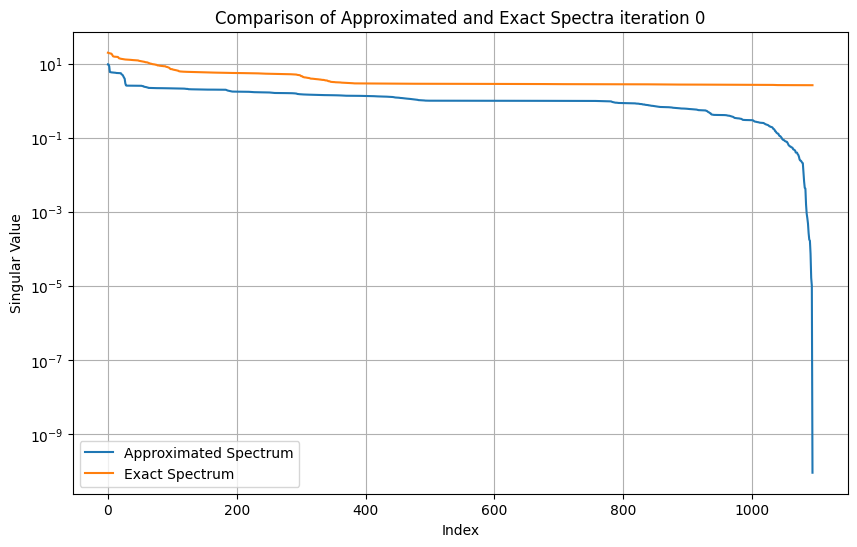

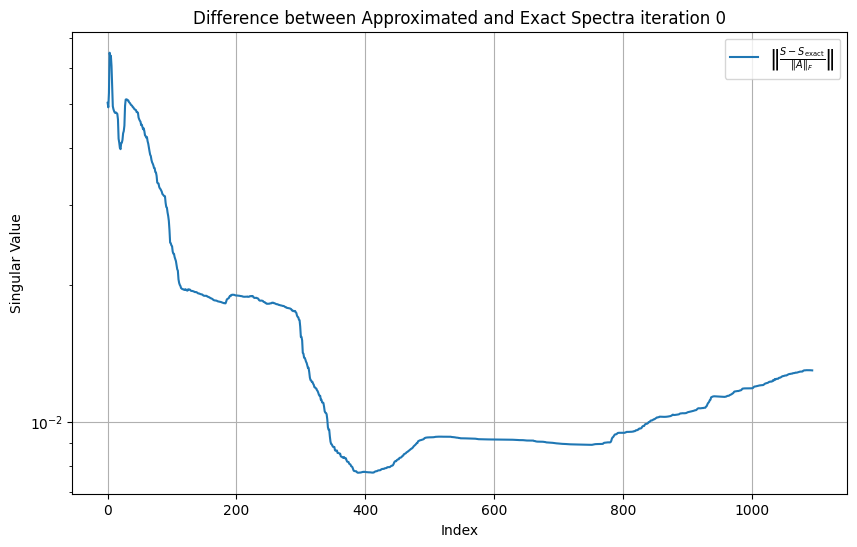

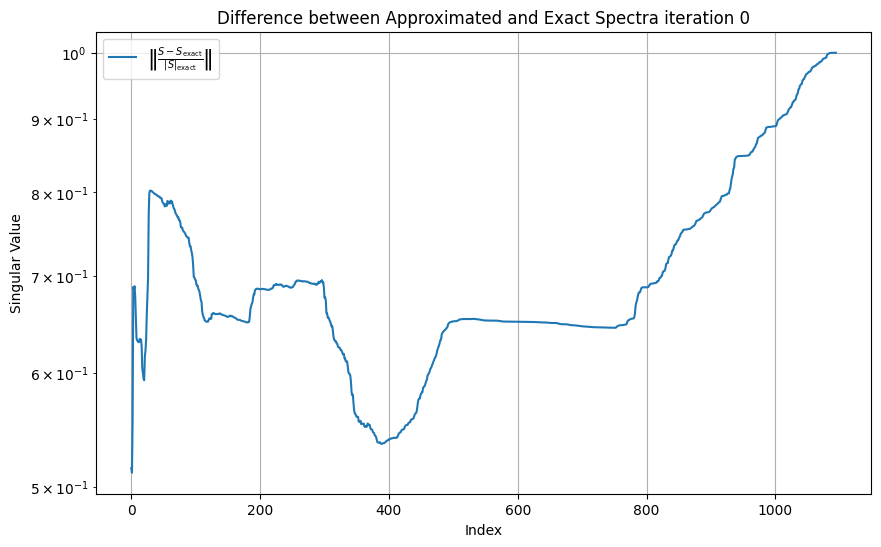

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Function to load and plot data
def load_and_plot(file_path, plot_type):
    data = np.load(file_path)
    
    plt.figure(figsize=(10, 6))
    
    if plot_type == 'spectrum':
        plt.plot(data['S'], label='Approximated Spectrum')
        plt.plot(data['S_exact'][:data['S'].shape[0]], label='Exact Spectrum')
        plt.xlabel('Index')
        plt.ylabel('Singular Value')
        plt.title(f'Comparison of Approximated and Exact Spectra iteration {data["iteration"]}')
        plt.legend()
    else:
        plt.plot(data['diff'], label=plot_type)
        plt.xlabel('Index')
        plt.ylabel('Singular Value')
        plt.title(f'Difference between Approximated and Exact Spectra iteration {data["iteration"]}')
        plt.legend()
    
    plt.grid(True)
    plt.yscale('log')
    plt.show()

# Directory where the data is saved
# matrix_postfix = 'temp'
# figure_dir = 'figures'
matrix_postfix = 'lhr11_original'
figure_dir = 'output'
dir_path = f"{figure_dir}/{matrix_postfix}/"

# Iteration number you want to plot
iteration = 0  # Change this to the iteration you want to plot

# Plot spectrum comparison
spectrum_file = os.path.join(dir_path, f'spectrum_data_{iteration}.npz')
load_and_plot(spectrum_file, 'spectrum')

# Plot difference relative to A_norm
diff_relA_file = os.path.join(dir_path, f'diffspec_relA_data_{iteration}.npz')
load_and_plot(diff_relA_file, '$\\left\\|\\frac{S-S_\\text{exact}}{\|A\|_F}\\right\\|$')

# Plot difference relative to S_exact
diff_relS_file = os.path.join(dir_path, f'diffspec_relS_data_{iteration}.npz')
load_and_plot(diff_relS_file, '$\\left\\|\\frac{S-S_\\text{exact}}{|S|_\\text{exact}}\\right\\|$')

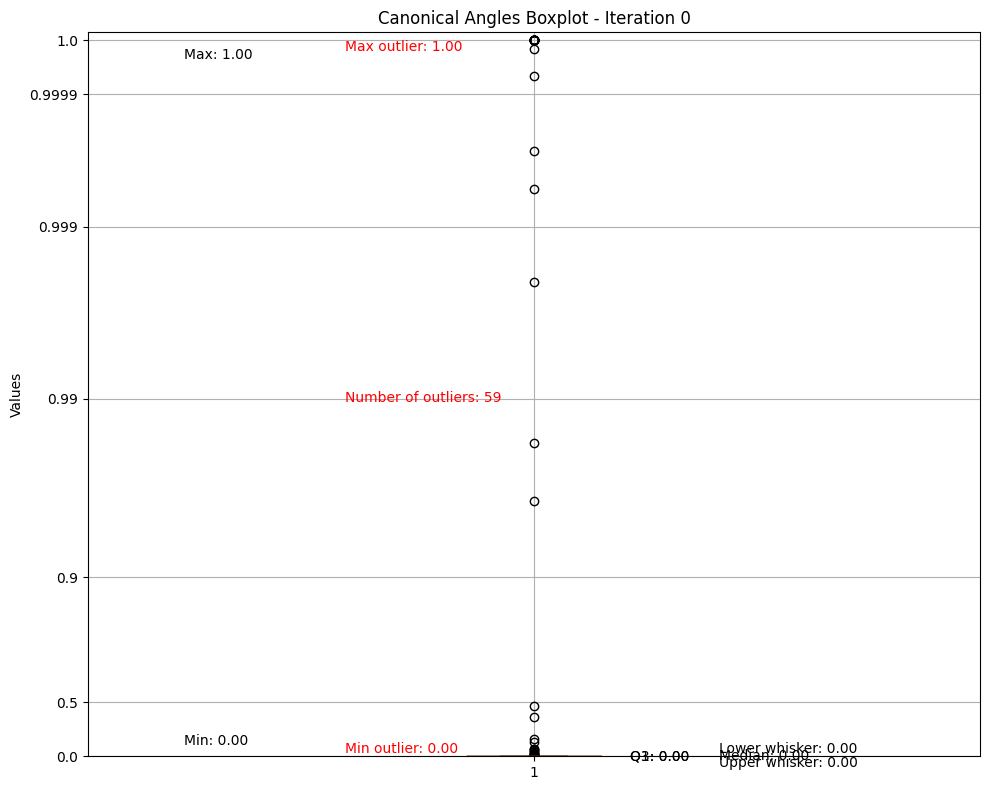

In [314]:
def load_and_plot_canonical_angles(file_path):
    # Load data
    data = np.load(file_path)
    s = data['s']
    iteration = data['iteration']

    # Create the boxplot
    fig, ax = plt.subplots(figsize=(10, 8))
    bp = ax.boxplot(s, whis=1.5)

    # Extract positions
    whiskers = [item.get_ydata()[1] for item in bp['whiskers']]
    caps = [item.get_ydata()[0] for item in bp['caps']]
    boxes = [item.get_ydata() for item in bp['boxes']][0]
    medians = [item.get_ydata()[0] for item in bp['medians']]
    fliers = bp['fliers'][0].get_ydata()

    # Calculate statistics
    min_val, max_val = np.min(s), np.max(s)
    q1, median_val, q3 = np.percentile(s, [25, 50, 75])
    lower_whisker, upper_whisker = whiskers[0], whiskers[1]

    # Function to add annotation with offset
    def add_annotation(x, y, text, offset=0, color='black', ha='left', va='center'):
        ax.annotate(text, (x, y), xytext=(offset, 0), textcoords='offset points',
                    ha=ha, va=va, color=color)

    def inverse_transform(s):
        return 1 - np.exp(-s)

    # Add annotations with adjusted positions
    add_annotation(0.6, min_val+0.1, f'Min: {inverse_transform(min_val):.2f}', offset=5, va='bottom')
    add_annotation(0.6, max_val-0.1, f'Max: {inverse_transform(max_val):.2f}', offset=5, va='top')
    add_annotation(1.1, q1, f'Q1: {inverse_transform(q1):.2f}', offset=5)
    add_annotation(1.1+0.1, median_val, f'Median: {inverse_transform(median_val):.2f}', offset=5)
    add_annotation(1.1, q3, f'Q3: {inverse_transform(q3):.2f}', offset=5)
    add_annotation(1.1+0.1, lower_whisker, f'Lower whisker: {inverse_transform(lower_whisker):.2f}', offset=5, va='bottom')
    add_annotation(1.1+0.1, upper_whisker, f'Upper whisker: {inverse_transform(upper_whisker):.2f}', offset=5, va='top')

    # Add outlier information
    if len(fliers) > 0:
        outlier_min, outlier_max = np.min(fliers), np.max(fliers)
        add_annotation(0.78, outlier_min, f'Min outlier: {inverse_transform(outlier_min):.2f}', offset=5, va='bottom', color='red')
        add_annotation(0.78, outlier_max, f'Max outlier: {inverse_transform(outlier_max):.2f}', offset=5, va='top', color='red')
        add_annotation(0.78, (outlier_min+outlier_max)/2, f'Number of outliers: {len(fliers)}', offset=5, va='center', color='red')

    # Customize the plot
    ax.set_title(f'Canonical Angles Boxplot - Iteration {iteration}')
    ax.set_ylabel('Values')
    ax.set_xlim(0.5, 1.5)  # Adjust x-axis limits to make room for annotations

    epsilon = 1e-4
    ax.set_ylim(0, -np.log(epsilon)+0.1)

    y_ticks = np.array([0, 0.5, 0.9, 0.99, 0.999, 0.9999, 1])
    ax.set_yticks(-np.log(1 - y_ticks + epsilon))
    ax.set_yticklabels([f"{y}" for y in y_ticks])

    plt.grid()
    plt.tight_layout()
    plt.show()


# Load and plot canonical angles data
canonical_angles_file = os.path.join(dir_path, f'canonical_angles_data_{iteration}.npz')
load_and_plot_canonical_angles(canonical_angles_file)

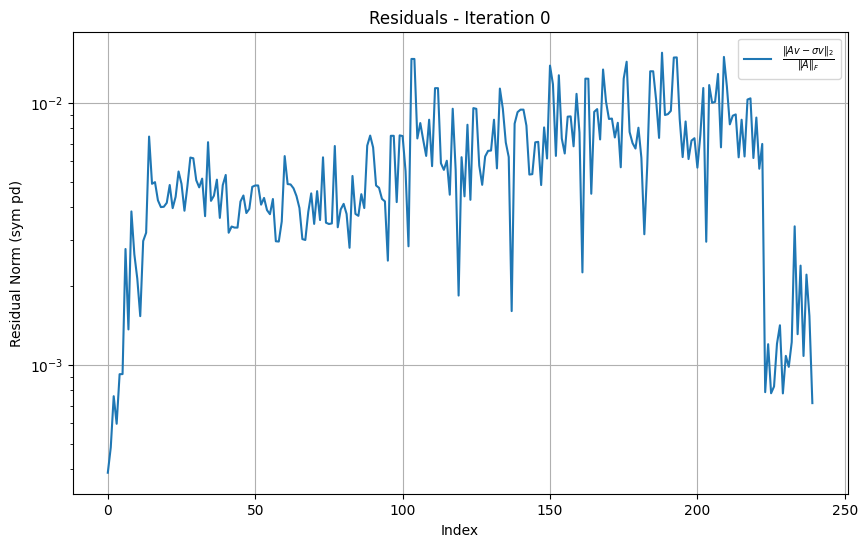

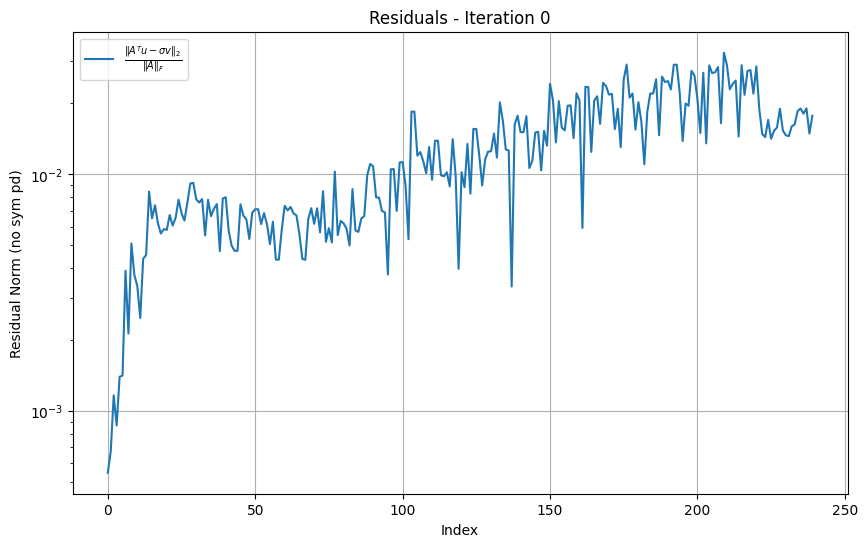

In [324]:
def load_and_plot_residuals(file_path, is_sym_psd=False):
    # Load data
    data = np.load(file_path)
    approx_residuals = data['approx_residuals']
    iteration = data['iteration']

    plt.figure(figsize=(10, 6))
    if is_sym_psd:
        plt.semilogy(approx_residuals, label='$\\frac{\|Av - \sigma v\|_2}{\|A\|_F}$')
        plt.ylabel('Residual Norm (sym pd)')
    else:
        plt.semilogy(approx_residuals, label='$\\frac{\|A^Tu - \sigma v\|_2}{\|A\|_F}$')
        plt.ylabel('Residual Norm (no sym pd)')

    plt.xlabel('Index')
    plt.title(f'Residuals - Iteration {iteration}')
    plt.legend()
    plt.grid(True)
    plt.show()

# Load and plot symmetric PSD residuals data (if available)
sym_psd_file = os.path.join(dir_path, f'residuals_sym_psd_data_{iteration}.npz')
if os.path.exists(sym_psd_file):
    load_and_plot_residuals(sym_psd_file, is_sym_psd=True)

# Load and plot non-symmetric PSD residuals data
residuals_file = os.path.join(dir_path, f'residuals_data_{iteration}.npz')
load_and_plot_residuals(residuals_file)

(2410,) [6.96198584e+07 5.36575188e+07 4.67668527e+07 ... 4.66410647e-04
 3.21009708e-04 7.65117745e-05]


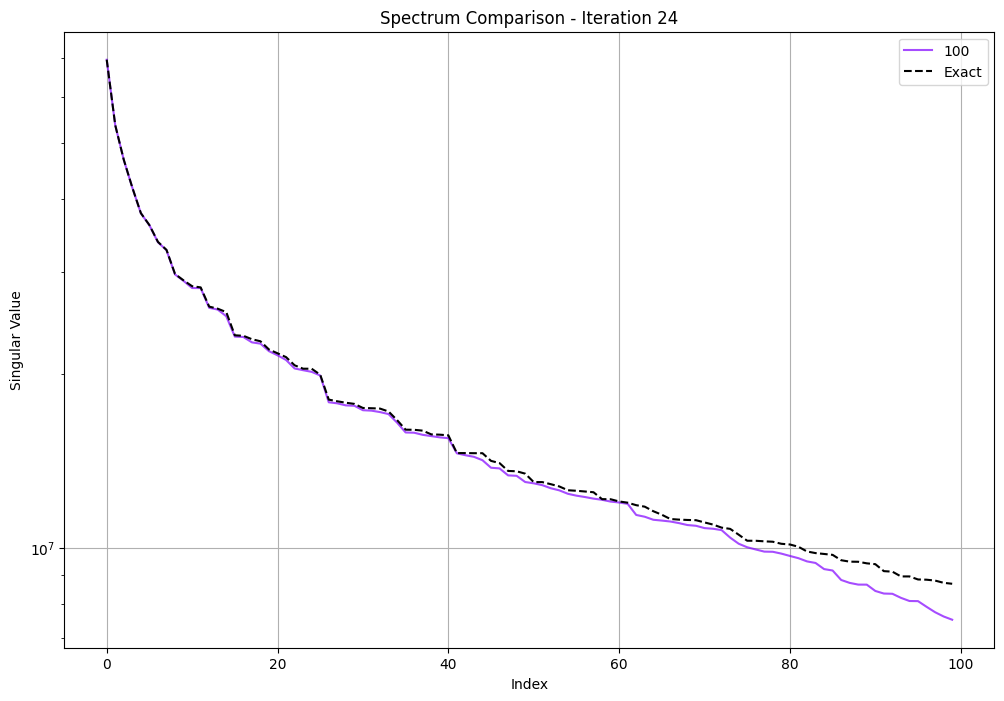

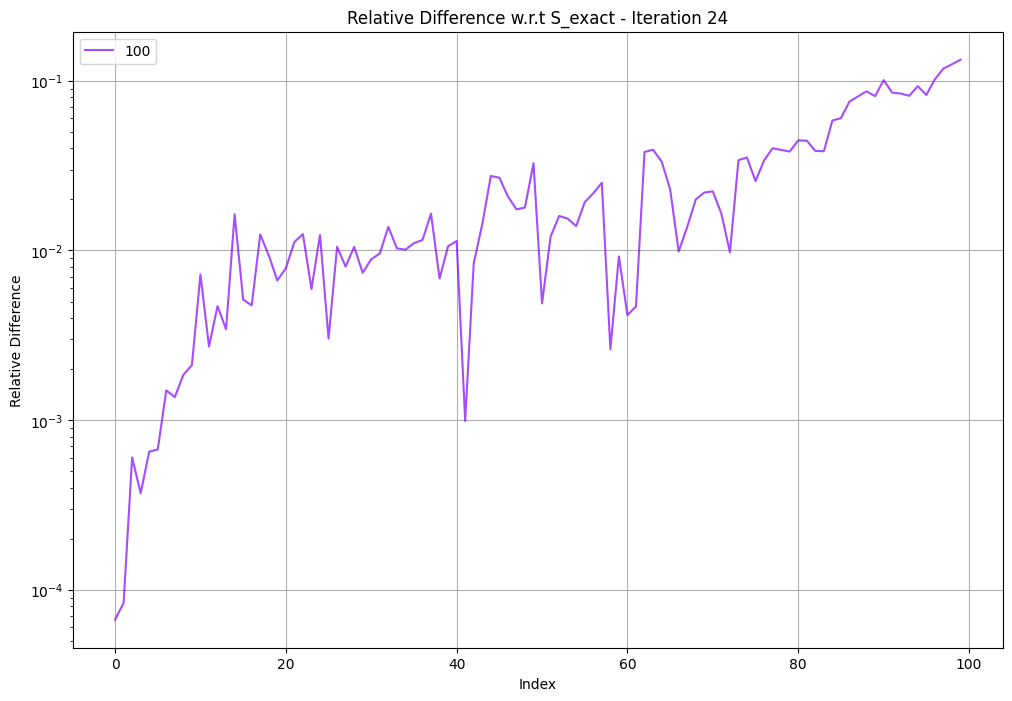

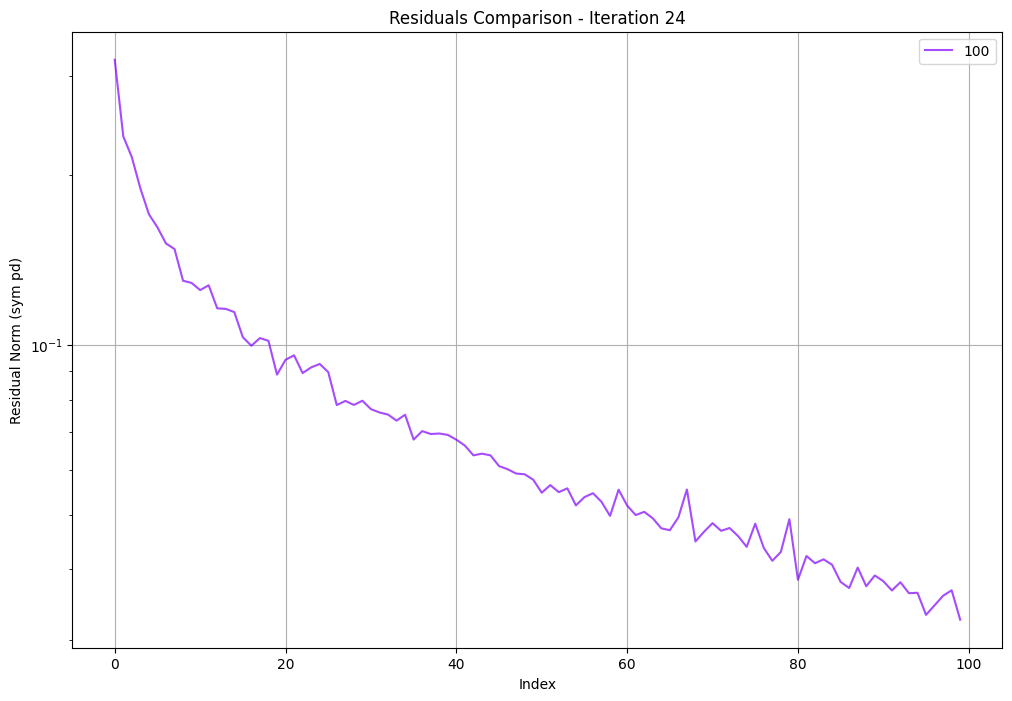

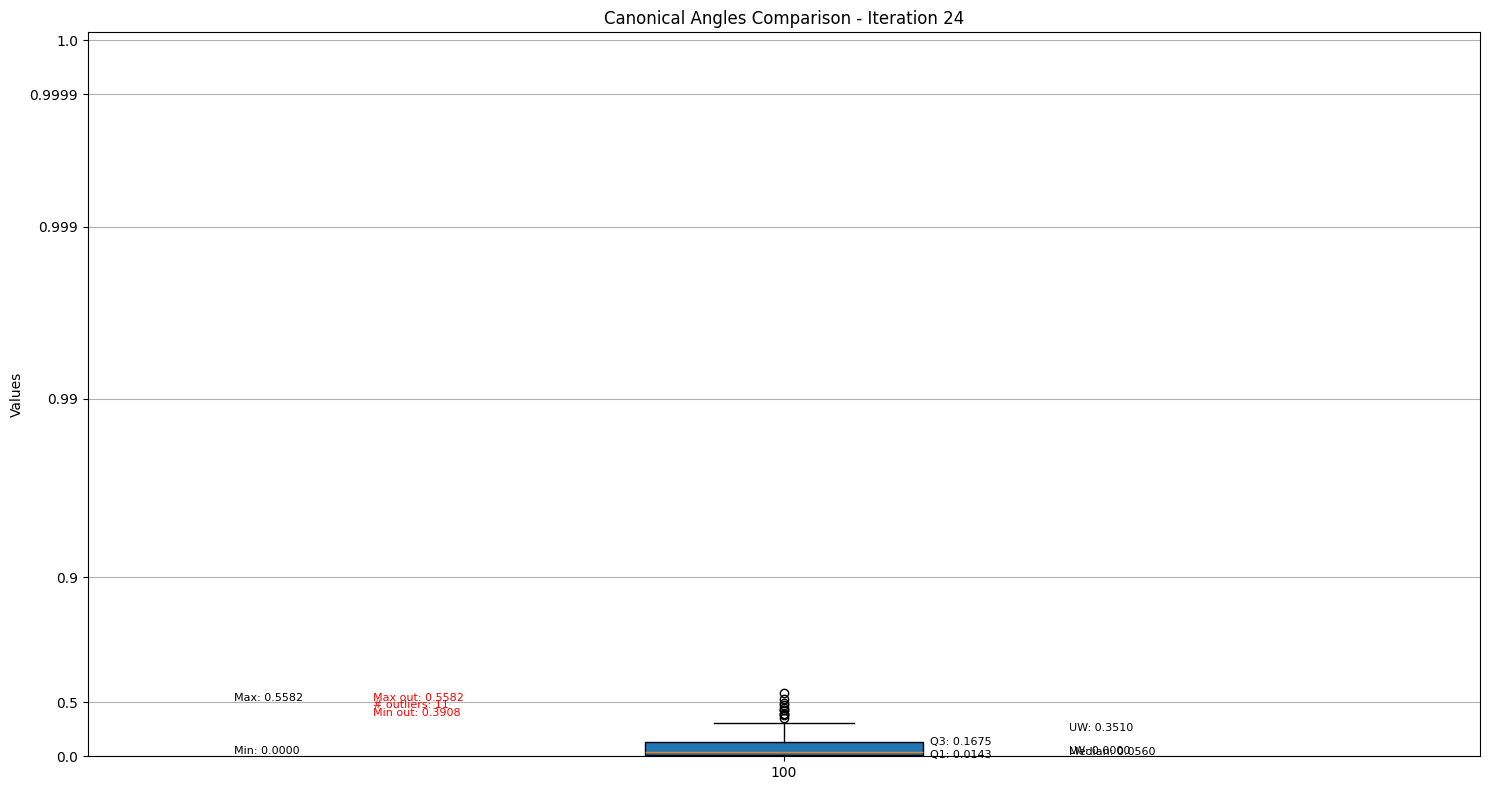

In [27]:
def load_and_plot_same_iteration_residuals(dir_paths, iteration, labels, is_sym_psd=False, save_path=None,
                                           colors=None, linestyles=None):
    plt.figure(figsize=(12, 8))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(dir_paths))) if colors is None else colors
    linestyles = ['-' for _ in colors] if linestyles is None else linestyles
    orig_iteration = iteration
    iterations = [iteration for _ in range(len(dir_paths))] if isinstance(iteration,int) else iteration

    for dir_path, label, color, linestyle, iteration in zip(dir_paths, labels, colors, linestyles, iterations):
        if is_sym_psd:
            file_path = os.path.join(dir_path, f'residuals_sym_psd_data_{iteration}.npz')
        else:
            file_path = os.path.join(dir_path, f'residuals_data_{iteration}.npz')
        
        try:
            data = np.load(file_path)
            approx_residuals = data['approx_residuals']
            plt.semilogy(approx_residuals, label=f'{label}', color=color, linestyle=linestyle, alpha=0.7)
#             if "exact" in label or "random" in label:
#                 plt.semilogy(approx_residuals, label=f'{label}', color=color, linestyle='--')
#             else:
#                 plt.semilogy(approx_residuals, label=f'{label}', color=color)
        except FileNotFoundError:
            print(f"File not found: {file_path}")

    if is_sym_psd:
        plt.ylabel('Residual Norm (sym pd)')
        plt.title(f'Residuals Comparison - Iteration {orig_iteration}')
    else:
        plt.ylabel('Residual Norm (not sym pd)')
        plt.title(f'Residuals Comparison - Iteration {orig_iteration}')

    plt.xlabel('Index')
    plt.legend()
#     plt.xlim([0,150])
    plt.grid(True)
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    
    plt.show()


def load_and_plot_spectrum_comparison(dir_paths, iteration, labels, save_dir=None,
                                      colors=None, linestyles=None, with_S_exact=True, 
                                      rel_A_norm=False):
    plt.figure(figsize=(12, 8))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(dir_paths))) if colors is None else colors
    linestyles = ['-' for _ in colors] if linestyles is None else linestyles
    orig_iteration = iteration
    iterations = [iteration for _ in range(len(dir_paths))] if isinstance(iteration,int) else iteration
    
    # Load exact spectrum from the first directory
    iteration = iterations[0]
    exact_file_path = os.path.join(dir_paths[0], f'spectrum_data_{iteration}.npz')
    exact_data = np.load(exact_file_path, allow_pickle=True)

    if with_S_exact:
        print(exact_data['S_exact'].shape, exact_data['S_exact'])
        S_exact = exact_data['S_exact']
    else:
        S_exact = None
    # A_norm = exact_data['A_norm']

    for dir_path, label, color, linestyle, iteration in zip(dir_paths, labels, colors, linestyles, iterations):
        file_path = os.path.join(dir_path, f'spectrum_data_{iteration}.npz')
        
        try:
            data = np.load(file_path)
            S = data['S']
            plt.semilogy(S, label=f'{label}', color=color, linestyle=linestyle, alpha=0.7)
#             if "exact" in label or "random" in label:
#                 plt.semilogy(S, label=f'{label}', color=color, linestyle='--', alpha=0.7)
#             else:
#                 plt.semilogy(S, label=f'{label}', color=color, linestyle='-', alpha=0.7)
        except FileNotFoundError:
            print(f"File not found: {file_path}")

    if not S_exact is None:
        plt.semilogy(S_exact[:len(S)], label='Exact', color='black', linestyle='--')

    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.title(f'Spectrum Comparison - Iteration {orig_iteration}')
    plt.legend()
    plt.grid(True)
    
    # if save_dir:
    #     plt.savefig(os.path.join(save_dir, f'spectrum_comparison_iteration_{iteration}.png'), bbox_inches='tight')
    
    plt.show()

    if S_exact is None:
        return
    # Plot relative difference to A_norm
    if rel_A_norm:
        plt.figure(figsize=(12, 8))
        for dir_path, label, color, linestyle, iteration in zip(dir_paths, labels, colors, linestyles, iterations):
            # file_path = os.path.join(dir_path, f'spectrum_data_{iteration}.npz')
            # Plot difference relative to A_norm
            file_path = os.path.join(dir_path, f'diffspec_relA_data_{iteration}.npz')
            data = np.load(file_path)
            
            # Plot difference relative to S_exact      
            try:
                data = np.load(file_path)            
                rel_diff = data['diff']
                plt.semilogy(rel_diff, label=f'{label}', color=color, linestyle=linestyle, alpha=0.7)
    #             if "exact" in label or "random" in label:
    #                 plt.semilogy(S, label=f'{label}', color=color, linestyle='--', alpha=0.7)
    #             else:
    #                 plt.semilogy(rel_diff, label=label, color=color, alpha=0.7)
            except FileNotFoundError:
                print(f"File not found: {file_path}")
    
        plt.xlabel('Index')
        plt.ylabel('Relative Difference')
        plt.title(f'Relative Difference w.r.t A_norm - Iteration {orig_iteration}')
        plt.legend()
        plt.grid(True)
        
        # if save_dir:
        #     plt.savefig(os.path.join(save_dir, f'spectrum_diff_relA_iteration_{iteration}.png'), bbox_inches='tight')
        
        plt.show()

    # Plot relative difference to S_exact
    plt.figure(figsize=(12, 8))
    for dir_path, label, color, linestyle, iteration in zip(dir_paths, labels, colors, linestyles, iterations):
        # file_path = os.path.join(dir_path, f'spectrum_data_{iteration}.npz')
        file_path = os.path.join(dir_path, f'diffspec_relS_data_{iteration}.npz')
        
        try:
            data = np.load(file_path)
            rel_diff = data['diff']
            plt.semilogy(rel_diff, label=label, color=color, linestyle=linestyle, alpha=0.7)
#             if "exact" in label or "random" in label:
#                 plt.semilogy(rel_diff, label=label, color=color, linestyle='--', alpha=0.7)
#             else:
#                 plt.semilogy(rel_diff, label=label, color=color, alpha=0.7)
        except FileNotFoundError:
            print(f"File not found: {file_path}")

    plt.xlabel('Index')
    plt.ylabel('Relative Difference')
    plt.title(f'Relative Difference w.r.t S_exact - Iteration {orig_iteration}')
    plt.legend()
    plt.grid(True)
    
    # if save_dir:
    #     plt.savefig(os.path.join(save_dir, f'spectrum_diff_relS_iteration_{iteration}.png'), bbox_inches='tight')
    
    plt.show()

def load_and_plot_multiple_canonical_angles(dir_paths, iteration, labels, save_path=None, additional_labels=""):
    fig, ax = plt.subplots(figsize=(15, 8))
    
    num_experiments = len(dir_paths)
    positions = np.arange(1, num_experiments + 1)
    width = 0.2
    
    all_data = []
    all_bp = []
    orig_iteration = iteration
    iterations = [iteration for _ in range(len(dir_paths))] if isinstance(iteration,int) else iteration

    for i, (dir_path, label, iteration) in enumerate(zip(dir_paths, labels, iterations)):
        file_path = os.path.join(dir_path, f'canonical_angles{additional_labels}_data_{iteration}.npz')
        
        try:
            data = np.load(file_path)
            s = data['s']
            all_data.append(s)
            
            bp = ax.boxplot(s, positions=[positions[i]], widths=width, patch_artist=True)
            all_bp.append(bp)
            
            # Customize colors
            # plt.setp(bp['boxes'], facecolor=plt.cm.Set3(i / num_experiments))
            
            # Calculate statistics
            min_val, max_val = np.min(s), np.max(s)
            q1, median_val, q3 = np.percentile(s, [25, 50, 75])
            whiskers = [item.get_ydata()[1] for item in bp['whiskers']]
            lower_whisker, upper_whisker = whiskers[0], whiskers[1]
            fliers = bp['fliers'][0].get_ydata()
            
            def inverse_transform(s):
                return 1 - np.exp(-s)
            
            # Function to add annotation with offset
            def add_annotation(x, y, text, offset=0, color='black', ha='left', va='center'):
                ax.annotate(text, (x, y), xytext=(offset, 0), textcoords='offset points',
                            ha=ha, va=va, color=color, fontsize=8)

            # print(median_val, max_val, inverse_transform(median_val), inverse_transform(max_val))
            # Add annotations
            x_pos = positions[i]
            add_annotation(x_pos-0.4, min_val, f'Min: {inverse_transform(min_val):.4f}', offset=5, va='bottom')
            add_annotation(x_pos-0.4, max_val, f'Max: {inverse_transform(max_val):.4f}', offset=5, va='top')
            add_annotation(x_pos+0.1, q1, f'Q1: {inverse_transform(q1):.4f}', offset=5)
            add_annotation(x_pos+0.2, median_val, f'Median: {inverse_transform(median_val):.4f}', offset=5)
            add_annotation(x_pos+0.1, q3, f'Q3: {inverse_transform(q3):.4f}', offset=5)
            add_annotation(x_pos+0.2, lower_whisker, f'LW: {inverse_transform(lower_whisker):.4f}', offset=5, va='bottom')
            add_annotation(x_pos+0.2, upper_whisker, f'UW: {inverse_transform(upper_whisker):.4f}', offset=5, va='top')
            
            # Add outlier information
            if len(fliers) > 0:
                outlier_min, outlier_max = np.min(fliers), np.max(fliers)
                add_annotation(x_pos-0.3, outlier_min, f'Min out: {inverse_transform(outlier_min):.4f}', offset=5, va='bottom', color='red')
                add_annotation(x_pos-0.3, outlier_max, f'Max out: {inverse_transform(outlier_max):.4f}', offset=5, va='top', color='red')
                add_annotation(x_pos-0.3, (outlier_min+outlier_max)/2, f'# outliers: {len(fliers)}', offset=5, va='center', color='red')
            
        except FileNotFoundError:
            print(f"File not found: {file_path}")
    
    # Customize the plot
    ax.set_title(f'Canonical Angles Comparison - Iteration {orig_iteration}')
    ax.set_ylabel('Values')
    ax.set_ylim(0, -np.log(1e-4)+0.1)
    
    y_ticks = np.array([0, 0.5, 0.9, 0.99, 0.999, 0.9999, 1])
    ax.set_yticks(-np.log(1 - y_ticks + 1e-4))
    ax.set_yticklabels([f"{y}" for y in y_ticks])
    
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    
    plt.grid(axis='y')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.5)
    
    plt.show()
    plt.close('all')

# def load_and_plot_spectrum_comparison(dir_paths_list, iteration, labels, save_dir=None):
#     plt.figure(figsize=(12, 8))
#     colors = plt.cm.rainbow(np.linspace(0, 1, len(dir_paths_list)))
    
#     # Load exact spectrum from the first directory of the first list
#     exact_file_path = os.path.join(dir_paths_list[0][0], f'spectrum_data_{iteration}.npz')
#     exact_data = np.load(exact_file_path)
#     S_exact = exact_data['S_exact']
    
#     for dir_paths, label, color in zip(dir_paths_list, labels, colors):
#         all_S = []
#         all_diff_relA = []
#         all_diff_relS = []
        
#         for dir_path in dir_paths:
#             file_path = os.path.join(dir_path, f'spectrum_data_{iteration}.npz')
#             diff_relA_path = os.path.join(dir_path, f'diffspec_relA_data_{iteration}.npz')
#             diff_relS_path = os.path.join(dir_path, f'diffspec_relS_data_{iteration}.npz')
            
#             try:
#                 data = np.load(file_path)
#                 S = data['S']
#                 all_S.append(S)
                
#                 diff_relA = np.load(diff_relA_path)['diff']
#                 all_diff_relA.append(diff_relA)
                
#                 diff_relS = np.load(diff_relS_path)['diff']
#                 all_diff_relS.append(diff_relS)
#             except FileNotFoundError:
#                 print(f"File not found in directory: {dir_path}")
        
#         # Calculate mean and std for S, diff_relA, and diff_relS
#         S_mean = np.mean(all_S, axis=0)
#         S_std = 10**np.std(np.log10(all_S), axis=0)
#         diff_relA_mean = np.mean(all_diff_relA, axis=0)
#         diff_relA_std = np.std((all_diff_relA), axis=0)
#         diff_relS_mean = np.mean(all_diff_relS, axis=0)
#         diff_relS_std = np.std((all_diff_relS), axis=0)
# #         print(diff_relS_std)
# #         print((np.log10(all_diff_relS)))
# #         if len(all_diff_relS) > 1:
# #             import pdb;pdb.set_trace()
        
#         # Plot spectrum
#         plt.semilogy(S_mean, label=f'{label}', color=color, linestyle='-')
#         plt.fill_between(range(len(S_mean)), S_mean - S_std, S_mean + S_std, color=color, alpha=0.3)
    
#     plt.semilogy(S_exact[:len(S_mean)], label='Exact', color='black', linestyle='--')
#     plt.xlabel('Index')
#     plt.ylabel('Singular Value')
#     plt.xlim([0,150])
#     plt.title(f'Spectrum Comparison - Iteration {iteration}')
#     plt.legend()
#     plt.grid(True)
    
#     if save_dir:
#         plt.savefig(os.path.join(save_dir, f'spectrum_comparison_iteration_{iteration}.png'), bbox_inches='tight')
    
#     plt.show()
    
#     # Plot relative difference to A_norm
#     plt.figure(figsize=(12, 8))
#     for dir_paths, label, color in zip(dir_paths_list, labels, colors):
#         plt.semilogy(diff_relA_mean, label=label, color=color)
#         plt.fill_between(range(len(diff_relA_mean)), diff_relA_mean - diff_relA_std, diff_relA_mean + diff_relA_std, color=color, alpha=0.3)
    
#     plt.xlabel('Index')
#     plt.ylabel('Relative Difference')
#     plt.title(f'Relative Difference w.r.t A_norm - Iteration {iteration}')
#     plt.legend()
#     plt.grid(True)
#     plt.xlim([0,150])
    
#     if save_dir:
#         plt.savefig(os.path.join(save_dir, f'spectrum_diff_relA_iteration_{iteration}.png'), bbox_inches='tight')
    
#     plt.show()
    
#     # Plot relative difference to S_exact
#     plt.figure(figsize=(12, 8))
#     for dir_paths, label, color in zip(dir_paths_list, labels, colors):
#         plt.semilogy(diff_relS_mean, label=label, color=color)
#         plt.fill_between(range(len(diff_relS_mean)), diff_relS_mean - diff_relS_std, diff_relS_mean + diff_relS_std, color=color, alpha=0.3)
    
#     plt.xlabel('Index')
#     plt.ylabel('Relative Difference')
#     plt.title(f'Relative Difference w.r.t S_exact - Iteration {iteration}')
#     plt.legend()
#     plt.grid(True)
#     plt.xlim([0,150])
    
#     if save_dir:
#         plt.savefig(os.path.join(save_dir, f'spectrum_diff_relS_iteration_{iteration}.png'), bbox_inches='tight')
    
#     plt.show()

matrix_name = None

# Example usage
matrix_name = 'temp'
figure_dir = 'figures'
# matrices = [f'{matrix_name}',]
# matrices = [f'{matrix_name}_{x}' for x in [100]]
# matrices = [f'{matrix_name}_{x}' for x in [10,20,40,60,80,100]]
colors = plt.cm.rainbow(np.linspace(0, 1, 6))
# matrices = {f'{matrix_name}': [colors[0], '-']}
# matrices = {f'{matrix_name}_{x}': [colors[i], '-'] for i, x in enumerate([10,20,40,60,80,100])}
matrices = {f'{matrix_name}_{x}': [colors[i], '-'] for i, x in enumerate([100])}


if not matrix_name:
    # matrix_postfix = 'ex10_original'
    # matrix_name = 'bcsstk36'
#     matrix_name = 'ex10'
    matrix_name = "hyperboloid_10000_1.0"
    figure_dir = 'output'
    # matrix_type = '_original'
    matrix_type = '_random_uniform'
#     matrix_type2 = '_random_uniform'
#     matrix_type3 = '_random_uniform_3'
#     matrix_type2 = '_original'
    sizes = [10, 20, 40, 60, 80, 100]
    size = 100
    
    # matrix_type = '_random_uniform_2'
    # matrix_type2 = '_random_uniform_3'
    # matrix_type3 = '_random_uniform_4'
    # matrix_type4 = '_random_uniform_5'
    
    num_Vs = 10
    # matrices = [f'{matrix_name}_original', f'{matrix_name}_decreasing_norm', f'{matrix_name}_decreasing_exactV_norm_1', f'{matrix_name}_decreasing_exactV_norm_10', f'{matrix_name}_decreasing_exactV_norm_100', f'{matrix_name}_decreasing_exactV_norm']
    #matrices = [f'{matrix_name}_original', f'{matrix_name}_decreasing_norm', f'{matrix_name}_Vapprox_1_random_uniform', f'{matrix_name}_Vapprox_10_random_uniform', f'{matrix_name}_Vapprox_100_random_uniform']
    # matrices = [f'{matrix_name}_original', f'{matrix_name}_decreasing_norm', f'{matrix_name}_Vapprox_1_original', f'{matrix_name}_Vapprox_10_original', f'{matrix_name}_Vapprox_100_original', 
    #             f'{matrix_name}_decreasing_exactV_norm_1', f'{matrix_name}_decreasing_exactV_norm_10', f'{matrix_name}_decreasing_exactV_norm_100']
    # matrices = [f'{matrix_name}_original', f'{matrix_name}_decreasing_norm', f'{matrix_name}_Vapprox_1_original', f'{matrix_name}_Vapprox_10_original', f'{matrix_name}_Vapprox_100_original', 
    #             f'{matrix_name}_decreasing_exactV_norm_1', f'{matrix_name}_decreasing_exactV_norm_10', f'{matrix_name}_decreasing_exactV_norm_100']
    # matrices = [f'{matrix_name}_original', f'{matrix_name}_decreasing_norm', f'{matrix_name}_Vapprox_1_random_uniform', f'{matrix_name}_Vapprox_withS_1_random_uniform']
    # matrices = [f'{matrix_name}_original', f'{matrix_name}_decreasing_norm', f'{matrix_name}_Vapprox_withS_{num_Vs}_original', f'{matrix_name}_Vapprox_{num_Vs}_original', f'{matrix_name}_Vapprox_reversed_{num_Vs}_original']
    # matrices = [f'{matrix_name}{matrix_type}', f'{matrix_name}_decreasing_norm', f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type}', f'{matrix_name}_Vapprox_{num_Vs}{matrix_type}', f'{matrix_name}_Vapprox_reversed_{num_Vs}{matrix_type}']
    matrices = [f'{matrix_name}{matrix_type}', f'{matrix_name}_decreasing_norm', 
                f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type}', f'{matrix_name}_Vapprox_{num_Vs}{matrix_type}', f'{matrix_name}_Vapprox_reversed_{num_Vs}{matrix_type}',
                f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type2}']
    # matrices.
    # print(labels)
    
    colors = plt.cm.rainbow(np.linspace(0, 1, 5))
    matrices = {
        f'{matrix_name}{matrix_type}_size_{size}': [colors[0], '-'], 
        f'{matrix_name}{matrix_type2}_size_{size}': [colors[0], ':'], 
#         f'{matrix_name}{matrix_type3}_size_{size}': [colors[0], '-.'], 
        f'{matrix_name}_decreasing_norm_size_{size}': [colors[1], '-.'],
    #     f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type}': [colors[2], '-'], 
    #     f'{matrix_name}_Vapprox_{num_Vs}{matrix_type}': [colors[3], '-'], 
    #     f'{matrix_name}_Vapprox_reversed_{num_Vs}{matrix_type}': [colors[4], '-']
    }
    
    # matrices.update({
    #     f'{matrix_name}_decreasing_exactV_norm_{num_Vs}': [colors[2+i], '-.'] for i, num_Vs in enumerate([1,10,100])
    # })
    # matrices.update({
    #     f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type}': [colors[2+i], '-'] for i, num_Vs in enumerate([1,10,100])
    # })
    # matrices.update({
    #     f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type2}': [colors[2+i], ':'] for i, num_Vs in enumerate([1,10,100])
    # })
    
#     matrices.update({
#         f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type}_size_{size}': [colors[2+i], '-'] for i, num_Vs in enumerate([1,10,100])
#     })
#     matrices.update({
#         f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type2}_size_{size}': [colors[2+i], ':'] for i, num_Vs in enumerate([1,10,100])
#     })
#     matrices.update({
#         f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type3}_size_{size}': [colors[2+i], '-.'] for i, num_Vs in enumerate([1,10,100])
#     })

#     colors = plt.cm.rainbow(np.linspace(0, 1, 6))
#     matrices = {
# #         f'{matrix_name}{matrix_type}_size_{sizes[x]}': [colors[x], '-'] 
# #         f'{matrix_name}{matrix_type2}_size_{sizes[x]}': [colors[x], '-'] 
# #         f'{matrix_name}_Vapprox_withS_{num_Vs}{matrix_type}_size_{sizes[x]}': [colors[x], '-'] 
# #         f'{matrix_name}_Vapprox_withS_{100}{matrix_type2}_size_{sizes[x]}': [colors[x], '-'] 
#         f'{matrix_name}_decreasing_norm_size_{sizes[x]}': [colors[x], '-'] 
#                                                                            for x in range(6)
#     }



dir_paths = [f"{figure_dir}/{matrix_postfix}/" for matrix_postfix in matrices]
labels = [' '.join(s.split('_')[1:]) for s in matrices]
label_colors = {k:v[0] for k,v in matrices.items()}
label_linestyles = {k:v[1] for k,v in matrices.items()}

# color_groups = {
#     '1': 'purple',
#     '10': 'green',
#     '100': 'red',
#     'default': 'blue',
# }

# linestyle_groups = {
#     'default': '-',
#     'exact': ':',
#     'approx': '-.',
# }

# def get_best_match(label, group_dict):
#     matches = [(k, v) for k, v in group_dict.items() if k in label]
#     if not matches:
#         return group_dict.get('default', list(group_dict.values())[0])
#     print(matches)
#     return max(matches, key=lambda x: len(x[0]))[1]

# label_colors = {label: get_best_match(label, color_groups) for label in labels}
# label_linestyles = {label: get_best_match(label, linestyle_groups) for label in labels}


# print(label_colors, label_linestyles)
label_colors = label_colors.values()
label_linestyles = label_linestyles.values()
# label_colors, label_linestyles = None, None

# colors = []


# load_and_plot_spectrum_comparison(
#     dir_paths, 
#     iteration_to_compare, 
#     labels, 
#     # is_sym_psd=True, 
# )

# matrices_list = [[f'{matrix_name}_original'], 
# #             [f'{matrix_name}_Vapprox_1_random_uniform', f'{matrix_name}_Vapprox_1_random_uniform_2', f'{matrix_name}_Vapprox_1_random_uniform_3'], 
#            ]
# matrices_list += [[f'{matrix_name}_decreasing_norm'], [f'{matrix_name}_Vapprox_1_original'], [f'{matrix_name}_Vapprox_10_original'], [f'{matrix_name}_Vapprox_100_original']]
# dir_paths = [[f"{figure_dir}/{matrix_postfix}/" for matrix_postfix in matrices] for matrices in matrices_list]


# Specify the iteration you want to compare across all experiments
iteration_to_compare = 24 # This will compare the 2nd iteration (index 1) across all experiments
# iteration_to_compare = [102,51,25,17,12,10]
# iteration_to_compare = last_available_file_number

load_and_plot_spectrum_comparison(
    dir_paths, 
    iteration_to_compare, 
    labels, 
    # is_sym_psd=True, 
    colors=label_colors,
    linestyles=label_linestyles,
    with_S_exact=True,
)

load_and_plot_same_iteration_residuals(
    dir_paths, 
    iteration_to_compare, 
    labels, 
    is_sym_psd=True, 
    colors=label_colors,
    linestyles=label_linestyles,
)

load_and_plot_multiple_canonical_angles(
    dir_paths, 
    iteration_to_compare, 
    labels, 
    # is_sym_psd=True, 
)

# load_and_plot_multiple_canonical_angles(
#     dir_paths, 
#     iteration_to_compare, 
#     labels, 
#     additional_labels="_U"
#     # is_sym_psd=True, 
# )